# Complete Hydrogen Permeation Model — Hierarchical Analysis

## Notebook Structure

| Section | Model | Description |
|---------|-------|-------------|
| **1** | L3+L4+L6 | Defective Oxide + Defective Metal + Surface Kinetics |
| **2** | L3+L4+L6 (no surface RL) | Same model, surface kinetics non-rate-limiting |
| **3** | L3+L4 | Defective Oxide + Defective Metal, no surface kinetics |
| **4** | Comparison | Three-way overlay of Sections 1, 2, 3 |

---

## Section 1 — L3+L4+L6: Full Model

**Physics:**
- **Oxide layer (L3):** Parallel path model — intact regions (molecular diffusion, Henry's law) + defect paths (pinholes, cracks, grain boundaries)
- **Metal layer (L4):** Effective diffusivity modified by grain boundary enhancement and Oriani trapping
- **Surface (L6):** Langmuir-Hinshelwood dissociation/recombination at the gas–oxide interface

**Governing equation:**

$$J_{total} = (1 - f_{defect})\,J_{intact}(D_{eff}) + f_{defect}\,J_{defect}(D_{eff})$$

where $D_{eff}$ accounts for grain boundary and trapping effects, and $J$ at each path is coupled to surface coverage $\theta$ via the L6 solver.

**Five analyses, each answering one physics question:**

| Cell | Plot | Question |
|------|------|----------|
| 1.4 | [A] Flux vs Pressure | How does system flux scale with $P_{up}$? |
| 1.6 | [C] Resistance Fractions | Which layer controls transport at each pressure? |
| 1.8 | [E] Path Breakdown | Which oxide path carries the flux? |
| 1.10 | [F] Arrhenius | What is the apparent $E_a$ per regime? |
| 1.12 | [H] Rate-Limiting Map | How does temperature shift the rate-limiting layer? |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys

# Add parent directory to path
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
# =============================================================================
# SECTION 1 | CELL 1 — SETUP
# Def_Oxide + Def_Metal + Surface : Defective Oxide + Defective Metal + Surface Kinetics
# Run once. All imports, config, and Arrhenius helpers.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import pandas as pd

from calculations.surface_kinetics import (
    calculate_full_model_flux_L346_v2,
    calculate_defective_metal_flux_L6,
)
from calculations.config.model_config import (
    R, F,
    METALS, OXIDES, OXIDE_DEFECTS, CONDITIONS, VALIDATION, MICROSTRUCTURE,
    PLOT_STYLE as STYLE, CURVE_STYLES, apply_style,
    build_simulation_config,
)

# ── Simulation config ─────────────────────────────────────────────────────────
SIM       = build_simulation_config(
    metal='metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985',
    oxide='Cr2O3_sample4',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

METAL_KEY = SIM['metal_name']
OXIDE_KEY = SIM['oxide_name']
METAL     = METALS[METAL_KEY]
OXIDE     = OXIDES[OXIDE_KEY]
SK_OX     = OXIDE['surface_kinetics']
SK_M      = METAL['surface_kinetics']

# ── Arrhenius helpers — oxide surface ─────────────────────────────────────────
def get_k_diss_at_T(T):
    return SK_OX['k_diss_ref'] * np.exp((-SK_OX['E_diss']  / R) * (1/T - 1/SK_OX['T_ref']))

def get_K_eq_at_T(T):
    return SK_OX['K_eq_ref']   * np.exp((-SK_OX['H_eq']    / R) * (1/T - 1/SK_OX['T_ref']))

# ── Arrhenius helpers — oxide transport ───────────────────────────────────────
def get_D_ox_at_T(T):
    return OXIDE['D_ox_ref'] * np.exp((-OXIDE['E_D_ox']  / R) * (1/T - 1/OXIDE['T_ref']))

def get_K_ox_at_T(T):
    return OXIDE['K_ox_ref'] * np.exp((-OXIDE['H_sol_ox'] / R) * (1/T - 1/OXIDE['T_ref']))

# ── Arrhenius helpers — metal transport ───────────────────────────────────────
def get_D_m_at_T(T):
    return METAL['D_ref']   * np.exp((-METAL['E_D'] / R) * (1/T - 1/METAL['T_ref']))

def get_K_s_at_T(T):
    return METAL['K_s_ref'] * np.exp((-METAL['H_s'] / R) * (1/T - 1/METAL['T_ref']))

# ── Arrhenius helpers — metal surface kinetics ────────────────────────────────
def get_k_diss_metal_at_T(T):
    return SK_M['k_diss_metal_ref'] * np.exp((-SK_M['E_diss_metal'] / R) * (1/T - 1/SK_M['T_ref']))

def get_K_eq_metal_at_T(T):
    return SK_M['K_eq_metal_ref']   * np.exp((-SK_M['H_eq_metal']   / R) * (1/T - 1/SK_M['T_ref']))

# ── D_eff helper ──────────────────────────────────────────────────────────────
def get_D_eff_at_T(T, mode, microstructure):
    try:
        r = calculate_defective_metal_flux_L6(
            SIM['P_upstream'], SIM['P_downstream'], SIM['L_metal'], T,
            get_k_diss_at_T(T), get_K_eq_at_T(T),
            get_D_m_at_T(T), get_K_s_at_T(T),
            microstructure, mode=mode,
        )
        return r.get('D_eff', get_D_m_at_T(T))
    except Exception:
        return get_D_m_at_T(T)

print("✓ Setup complete")
print(f"  Metal : {METAL_KEY}")
print(f"  Oxide : {OXIDE_KEY}")
print(f"  T_op  : {SIM['T_operating']} K  ({SIM['T_operating']-273.15:.0f} °C)")

✓ Setup complete
  Metal : metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  Oxide : Cr2O3_sample4
  T_op  : 873 K  (600 °C)


In [3]:
# =============================================================================
# SECTION 1 | CELL 2 — PARAMETERS
# All physics values at T_op pulled from helpers.
# No computation here — scalars only.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
L_m    = SIM['L_metal']
P_up   = SIM['P_upstream']
P_down = SIM['P_downstream']

# ── Oxide surface kinetics at T_op ────────────────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Metal transport at T_op ───────────────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_at_T(T_op)

# ── Metal surface kinetics at T_op ────────────────────────────────────────────
k_diss_metal = get_k_diss_metal_at_T(T_op)
K_eq_metal   = get_K_eq_metal_at_T(T_op)

# ── Microstructure ────────────────────────────────────────────────────────────
microstructure = SIM['microstructure']
mode           = microstructure.get('mode', 'both')
grain_size     = microstructure['grain_size']

# ── D_eff at T_op ─────────────────────────────────────────────────────────────
D_eff = get_D_eff_at_T(T_op, mode, microstructure)

# ── Defect configuration ──────────────────────────────────────────────────────
defect_config        = SIM['defect_config']
use_sieverts_pinhole = SIM['oxide_defects'].get('use_sieverts_pinhole', False)
k_diss_metal_arg     = None if use_sieverts_pinhole else k_diss_metal
K_eq_metal_arg       = None if use_sieverts_pinhole else K_eq_metal

# ── Derived resistance scales ─────────────────────────────────────────────────
R_surface = 1 / k_diss                  # surface resistance proxy
R_oxide   = L_ox / (D_ox * K_ox)        # oxide resistance
R_metal   = L_m  / (D_eff * K_s_m)      # metal resistance (using D_eff)

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"Def_Oxide + Def_Metal + Surface Model PARAMETERS  |  T = {T_op-273.15:.0f} °C  ({T_op} K)")
print("=" * 60)
print(f"\n  Geometry")
print(f"    L_ox   = {L_ox:.3e} m")
print(f"    L_m    = {L_m:.3e} m")
print(f"    P_up   = {P_up:.3e} Pa")
print(f"    P_down = {P_down:.3e} Pa")
print(f"\n  Oxide surface kinetics")
print(f"    k_diss   = {k_diss:.3e} mol/m²/s/Pa")
print(f"    k_recomb = {k_recomb:.3e} m⁴/mol/s")
print(f"    K_eq     = {K_eq:.3e} Pa⁻¹")
print(f"\n  Oxide transport")
print(f"    D_ox   = {D_ox:.3e} m²/s")
print(f"    K_ox   = {K_ox:.3e} mol/m³/Pa^0.5")
print(f"\n  Metal transport")
print(f"    D_m    = {D_m:.3e} m²/s")
print(f"    D_eff  = {D_eff:.3e} m²/s  (mode={mode})")
print(f"    K_s_m  = {K_s_m:.3e} mol/m³/Pa^0.5")
print(f"\n  Defect configuration")
for path, cfg in defect_config.items():
    print(f"    {path:<16} f = {cfg['area_fraction']*100:.3f}%")
print(f"\n  Resistance proxies (relative)")
print(f"    R_surface = {R_surface:.3e}")
print(f"    R_oxide   = {R_oxide:.3e}")
print(f"    R_metal   = {R_metal:.3e}")
print(f"    Dominant  : {'surface' if R_surface == max(R_surface, R_oxide, R_metal) else 'oxide' if R_oxide == max(R_surface, R_oxide, R_metal) else 'metal'}")

Def_Oxide + Def_Metal + Surface Model PARAMETERS  |  T = 600 °C  (873 K)

  Geometry
    L_ox   = 4.800e-08 m
    L_m    = 1.000e-03 m
    P_up   = 1.000e+05 Pa
    P_down = 0.000e+00 Pa

  Oxide surface kinetics
    k_diss   = 2.370e-09 mol/m²/s/Pa
    k_recomb = 8.468e+01 m⁴/mol/s
    K_eq     = 2.799e-11 Pa⁻¹

  Oxide transport
    D_ox   = 1.395e-17 m²/s
    K_ox   = 2.869e+02 mol/m³/Pa^0.5

  Metal transport
    D_m    = 2.487e-10 m²/s
    D_eff  = 2.487e-10 m²/s  (mode=both)
    K_s_m  = 3.834e-02 mol/m³/Pa^0.5

  Defect configuration
    pinhole          f = 1.000%
    crack            f = 0.500%
    grain_boundary   f = 0.500%

  Resistance proxies (relative)
    R_surface = 4.219e+08
    R_oxide   = 1.200e+07
    R_metal   = 1.049e+08
    Dominant  : surface


In [4]:
# =============================================================================
# SECTION 1 | CELL 3 — COMPUTE
# All arrays built here. Three sweeps:
#   (i)  Pressure sweep at T_op        → Plots A, C, E
#   (ii) Temperature sweep at P_up     → Plot F (Arrhenius)
#   (iii) Pressure sweep at 5 T values → Plot H (rate-limiting map)
# =============================================================================

# ── Sweep grids ───────────────────────────────────────────────────────────────
P_ARR = np.logspace(
    np.log10(CONDITIONS['P_range'][0]),
    np.log10(CONDITIONS['P_range'][1]),
    CONDITIONS['n_P_points'],
)
T_ARR = np.linspace(*CONDITIONS['T_range'], CONDITIONS['n_T_points'])
T_5   = np.linspace(*CONDITIONS['T_range'], 5)
# ── Helper: single call to full model ─────────────────────────────────────────

def run_full_model(P_up, T):
    k_d   = get_k_diss_at_T(T)
    K_e   = get_K_eq_at_T(T)
    D_o   = get_D_ox_at_T(T)
    K_o   = get_K_ox_at_T(T)
    D_met = get_D_m_at_T(T)
    K_s   = get_K_s_at_T(T)
    kdm   = get_k_diss_metal_at_T(T)  if not use_sieverts_pinhole else None
    Keqm  = get_K_eq_metal_at_T(T)    if not use_sieverts_pinhole else None
    return calculate_full_model_flux_L346_v2(
        P_up, P_down, L_m, T,
        k_d, K_e,
        D_o, K_o, L_ox,
        D_met, K_s,
        microstructure, defect_config,
        k_diss_metal=kdm,
        K_eq_metal=Keqm,
        mode=mode,
    )

# ── (i) Pressure sweep at T_op ────────────────────────────────────────────────
n_P = len(P_ARR)

J_arr            = np.full(n_P, np.nan)
frac_surface_arr = np.full(n_P, np.nan)
frac_oxide_arr   = np.full(n_P, np.nan)
frac_metal_arr   = np.full(n_P, np.nan)
frac_intact_arr  = np.full(n_P, np.nan)
frac_pinhole_arr = np.full(n_P, np.nan)
frac_crack_arr   = np.full(n_P, np.nan)
frac_gb_arr      = np.full(n_P, np.nan)
J_intact_arr     = np.full(n_P, np.nan)
J_pinhole_arr    = np.full(n_P, np.nan)
J_crack_arr      = np.full(n_P, np.nan)
J_gb_arr         = np.full(n_P, np.nan)
enhancement_arr  = np.full(n_P, np.nan)
D_eff_avg_arr    = np.full(n_P, np.nan)
rate_lim_arr     = np.empty(n_P, dtype=object)
dominant_path_arr= np.empty(n_P, dtype=object)

for i, P in enumerate(P_ARR):
    try:
        r  = run_full_model(P, T_op)
        fb = r['flux_breakdown']
        rs = r.get('flux_weighted_resistances')

        J_arr[i]             = r['J_total']
        enhancement_arr[i]   = r.get('enhancement_vs_intact', np.nan)
        D_eff_avg_arr[i]     = r.get('D_eff_avg', np.nan)
        dominant_path_arr[i] = r.get('dominant_path', 'unknown')
        rate_lim_arr[i]      = r.get('system_rate_limiting', 'unknown')

        frac_intact_arr[i]   = fb.get('intact',        {}).get('fraction_of_total', np.nan)
        frac_pinhole_arr[i]  = fb.get('pinhole',        {}).get('fraction_of_total', np.nan)
        frac_crack_arr[i]    = fb.get('crack',          {}).get('fraction_of_total', np.nan)
        frac_gb_arr[i]       = fb.get('grain_boundary', {}).get('fraction_of_total', np.nan)

        J_intact_arr[i]      = fb.get('intact',        {}).get('flux', np.nan)
        J_pinhole_arr[i]     = fb.get('pinhole',        {}).get('flux', np.nan)
        J_crack_arr[i]       = fb.get('crack',          {}).get('flux', np.nan)
        J_gb_arr[i]          = fb.get('grain_boundary', {}).get('flux', np.nan)

        if rs is not None:
            frac_surface_arr[i] = rs['fraction_surface']
            frac_oxide_arr[i]   = rs['fraction_oxide']
            frac_metal_arr[i]   = rs['fraction_metal']

    except Exception as e:
        rate_lim_arr[i]      = 'error'
        dominant_path_arr[i] = 'error'

valid_P = np.isfinite(J_arr) & (J_arr > 0)

# ── P_for_Ea — median of pure dominant pressure points ───────────────────────
res_valid = valid_P & np.isfinite(frac_surface_arr)
P_for_surface_Ea = np.median(P_ARR[(frac_surface_arr > 0.90) & res_valid]) \
                   if np.sum((frac_surface_arr > 0.90) & res_valid) > 3 else None
P_for_oxide_Ea   = np.median(P_ARR[(frac_oxide_arr   > 0.90) & res_valid]) \
                   if np.sum((frac_oxide_arr   > 0.90) & res_valid) > 3 else None
P_for_metal_Ea   = np.median(P_ARR[(frac_metal_arr   > 0.90) & res_valid]) \
                   if np.sum((frac_metal_arr   > 0.90) & res_valid) > 3 else None

print(f"✓ Pressure sweep: {valid_P.sum()}/{n_P} points converged")
print(f"  P_for_surface_Ea = {P_for_surface_Ea:.3e} Pa" if P_for_surface_Ea else "  P_for_surface_Ea = None")
print(f"  P_for_oxide_Ea   = {P_for_oxide_Ea:.3e} Pa"   if P_for_oxide_Ea   else "  P_for_oxide_Ea   = None")
print(f"  P_for_metal_Ea   = {P_for_metal_Ea:.3e} Pa"   if P_for_metal_Ea   else "  P_for_metal_Ea   = None")

# ── (ii) Temperature sweep at P_up ────────────────────────────────────────────
n_T    = len(T_ARR)
J_T    = np.full(n_T, np.nan)
RL_T   = np.empty(n_T, dtype=object)

for i, T in enumerate(T_ARR):
    try:
        r        = run_full_model(P_up, T)
        J_T[i]   = r['J_total']
        RL_T[i]  = r.get('system_rate_limiting', 'UNKNOWN')
    except Exception:
        RL_T[i] = 'ERROR'

valid_T = np.isfinite(J_T) & (J_T > 0)
print(f"✓ Temperature sweep: {valid_T.sum()}/{n_T} points converged")

# ── (iii) Pressure sweep at 5 temperatures ────────────────────────────────────
frac_surface_5T = np.full((len(T_5), len(P_ARR)), np.nan)
frac_oxide_5T   = np.full((len(T_5), len(P_ARR)), np.nan)
frac_metal_5T   = np.full((len(T_5), len(P_ARR)), np.nan)

for j, T in enumerate(T_5):
    for i, P in enumerate(P_ARR):
        try:
            r  = run_full_model(P, T)
            rs = r.get('flux_weighted_resistances')
            if rs is not None:
                frac_surface_5T[j, i] = rs['fraction_surface']
                frac_oxide_5T[j, i]   = rs['fraction_oxide']
                frac_metal_5T[j, i]   = rs['fraction_metal']
        except Exception:
            pass

print(f"✓ 5-temperature sweep: complete")
print(f"  T values: {[f'{T-273.15:.0f}°C' for T in T_5]}")

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 873.0 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.92 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.91 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.90 > 0.9. Approaching saturat

✓ Pressure sweep: 40/40 points converged
  P_for_surface_Ea = None
  P_for_oxide_Ea   = None
  P_for_metal_Ea   = 1.549e+07 Pa
✓ Temperature sweep: 20/20 points converged


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.90×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.91×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.92×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.93×) nearly cancel. Small parameter c

✓ 5-temperature sweep: complete
  T values: ['350°C', '494°C', '638°C', '783°C', '927°C']


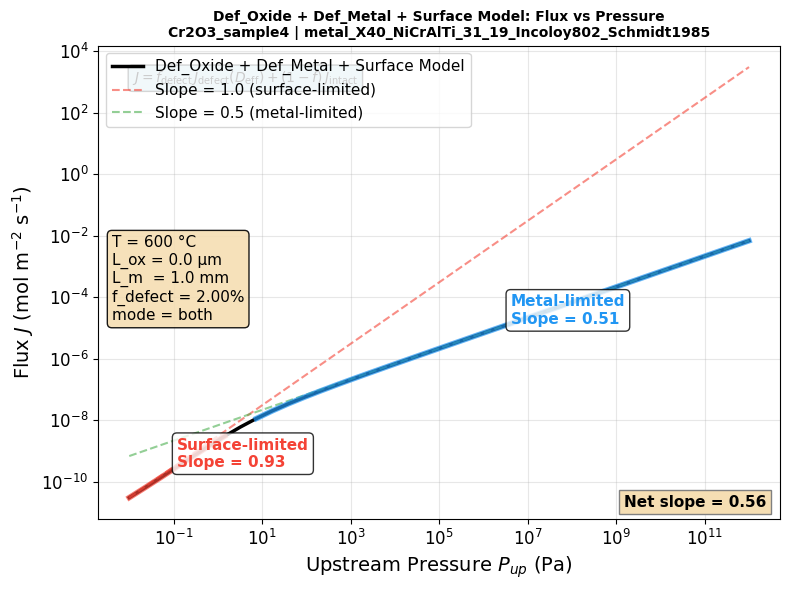

In [5]:
# =============================================================================
# SECTION 1 | CELL 4 — PLOT [A]: Flux vs Pressure
# Question: How does the full system flux scale with upstream pressure,
#           and which layer is rate-limiting at each pressure?
# =============================================================================
from itertools import groupby
from operator import itemgetter
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ── Base black curve ──────────────────────────────────────────────────────────
ax.loglog(
    P_ARR[valid_P], J_arr[valid_P],
    color='black', lw=STYLE['linewidth'],
    label='Def_Oxide + Def_Metal + Surface Model'
)

# ── Slope reference lines ─────────────────────────────────────────────────────
P_ref1  = P_ARR[valid_P][0]
J_ref1  = J_arr[valid_P][0]
ax.loglog(
    P_ARR[valid_P],
    J_ref1 * (P_ARR[valid_P] / P_ref1) ** 1.0,
    color=CURVE_STYLES['slope_1']['color'],
    ls=CURVE_STYLES['slope_1']['ls'],
    lw=CURVE_STYLES['slope_1']['lw'],
    alpha=CURVE_STYLES['slope_1']['alpha'],
    label='Slope = 1.0 (surface-limited)'
)

P_ref05 = P_ARR[valid_P][-1]
J_ref05 = J_arr[valid_P][-1]
ax.loglog(
    P_ARR[valid_P],
    J_ref05 * (P_ARR[valid_P] / P_ref05) ** 0.5,
    color=CURVE_STYLES['slope_05']['color'],
    ls=CURVE_STYLES['slope_05']['ls'],
    lw=CURVE_STYLES['slope_05']['lw'],
    alpha=CURVE_STYLES['slope_05']['alpha'],
    label='Slope = 0.5 (metal-limited)'
)

# ── Colored regime segments + slope annotation boxes ─────────────────────────
region_styles = [
    ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
    ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
    ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
    ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
]

for regime, color, label in region_styles:
    mask = (rate_lim_arr == regime) & valid_P
    if not np.any(mask):
        continue
    idxs = np.where(mask)[0]
    for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
        group = list(map(itemgetter(1), g))
        if len(group) < 3:
            continue
        P_seg = P_ARR[group]
        J_seg = J_arr[group]
        ax.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
        slope_seg, *_ = stats.linregress(
            np.log10(P_seg), np.log10(np.abs(J_seg))
        )
        mid = len(group) // 2
        ax.text(
            P_seg[mid], J_seg[mid],
            f'{label}\nSlope = {slope_seg:.2f}',
            color=color,
            fontsize=STYLE['fontsize_annotation'],
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# ── Net slope annotation ──────────────────────────────────────────────────────
slope_net, *_ = stats.linregress(
    np.log10(P_ARR[valid_P]),
    np.log10(np.abs(J_arr[valid_P]))
)
ax.text(
    0.98, 0.02, f'Net slope = {slope_net:.2f}',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=STYLE['fontsize_annotation'], fontweight='bold',
    bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
)

# ── Formula annotation ────────────────────────────────────────────────────────
ax.text(
    0.05, 0.95,
    r'$J = f_{\rm defect}\,J_{\rm defect}(D_{\rm eff}) + (1-f)\,J_{\rm intact}$',
    transform=ax.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
)

# ── Operating conditions box ──────────────────────────────────────────────────
total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}"
)
ax.text(
    0.02, 0.60, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)',  fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Def_Oxide + Def_Metal + Surface Model: Flux vs Pressure\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [6]:
# =============================================================================
# SECTION 1 | CELL 5 — TABLE [A]: Flux vs Pressure
# =============================================================================

df_A = pd.DataFrame({
    'P_up (Pa)':          P_ARR[valid_P],
    'J_total (mol/m²/s)': J_arr[valid_P],
    'log10(P)':           np.log10(P_ARR[valid_P]),
    'log10(J)':           np.log10(J_arr[valid_P]),
    'rate_limiting':      rate_lim_arr[valid_P],
    'dominant_path':      dominant_path_arr[valid_P],
    'J_intact':           J_intact_arr[valid_P],
    'J_pinhole':          J_pinhole_arr[valid_P],
    'J_crack':            J_crack_arr[valid_P],
    'J_grain_boundary':   J_gb_arr[valid_P],
    'enhancement_factor': enhancement_arr[valid_P],
    'D_eff_avg (m²/s)':   D_eff_avg_arr[valid_P],
    'D_eff_avg/D_m':      D_eff_avg_arr[valid_P] / D_m,
})

# Local slope
log_P      = np.log10(P_ARR[valid_P])
log_J      = np.log10(J_arr[valid_P])
local_slope        = np.full(len(log_P), np.nan)
local_slope[1:-1]  = (log_J[2:] - log_J[:-2]) / (log_P[2:] - log_P[:-2])
df_A['local_slope'] = local_slope

# Format
df_A_display = df_A.copy()
float_sci = ['P_up (Pa)', 'J_total (mol/m²/s)', 'J_intact', 'J_pinhole',
             'J_crack', 'J_grain_boundary', 'D_eff_avg (m²/s)']
float_round4 = ['enhancement_factor', 'D_eff_avg/D_m']
float_round3 = ['log10(P)', 'log10(J)', 'local_slope']

for col in float_sci:
    df_A_display[col] = df_A_display[col].apply(
        lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
    )
for col in float_round4:
    df_A_display[col] = df_A_display[col].round(4)
for col in float_round3:
    df_A_display[col] = df_A_display[col].round(3)

print("=" * 60)
print(f"TABLE [A]: Flux vs Pressure  |  T = {T_op-273.15:.0f} °C  |  {valid_P.sum()} points")
print("=" * 60)
display(df_A_display)

print("\n  Regime point counts:")
for regime in ['surface', 'oxide', 'metal', 'mixed']:
    n = (df_A['rate_limiting'] == regime).sum()
    if n > 0:
        print(f"    {regime:<10} : {n} pts")

print("\n  Dominant path counts:")
for path in ['intact', 'pinhole', 'crack', 'grain_boundary']:
    n = (df_A['dominant_path'] == path).sum()
    if n > 0:
        print(f"    {path:<16} : {n} pts")

TABLE [A]: Flux vs Pressure  |  T = 600 °C  |  40 points


,P_up (Pa),J_total (mol/m²/s),log10(P),log10(J),rate_limiting,dominant_path,J_intact,J_pinhole,J_crack,J_grain_boundary,enhancement_factor,D_eff_avg (m²/s),D_eff_avg/D_m,local_slope
0,1.0000e-02,3.0247e-11,-2.000,-10.519,surface,intact,2.3673e-11,6.8105e-10,2.3677e-11,2.3677e-11,1.2777,1.9240e-10,0.7737,NaN
1,2.2855e-02,6.4057e-11,-1.641,-10.193,surface,intact,5.4019e-11,1.0578e-09,5.4040e-11,5.4040e-11,1.1858,1.9240e-10,0.7737,0.918
2,5.2233e-02,1.3807e-10,-1.282,-9.860,surface,intact,1.2302e-10,1.6280e-09,1.2313e-10,1.2313e-10,1.1223,1.9240e-10,0.7737,0.936
3,1.1938e-01,3.0105e-10,-0.923,-9.521,surface,intact,2.7893e-10,2.4905e-09,2.7949e-10,2.7949e-10,1.0793,1.9240e-10,0.7737,0.945
4,2.7283e-01,6.5813e-10,-0.564,-9.182,surface,intact,6.2642e-10,3.7947e-09,6.2912e-10,6.2912e-10,1.0506,1.9240e-10,0.7737,0.940
5,6.2355e-01,1.4237e-09,-0.205,-8.847,surface,intact,1.3797e-09,5.7666e-09,1.3920e-09,1.3920e-09,1.0319,1.9240e-10,0.7737,0.916
6,1.4251e+00,2.9923e-09,0.154,-8.524,surface,intact,2.9337e-09,8.7478e-09,2.9833e-09,2.9833e-09,1.0200,1.9240e-10,0.7737,0.869
7,3.2570e+00,5.9896e-09,0.513,-8.223,mixed,intact,5.9146e-09,1.3255e-08,6.0807e-09,6.0807e-09,1.0127,1.9240e-10,0.7737,0.803
8,7.4438e+00,1.1280e-08,0.872,-7.948,metal,intact,1.1186e-08,2.0068e-08,1.1639e-08,1.1639e-08,1.0083,1.9240e-10,0.7737,0.730
9,1.7013e+01,2.0011e-08,1.231,-7.699,metal,intact,1.9896e-08,3.0369e-08,2.0921e-08,2.0921e-08,1.0058,1.9240e-10,0.7737,0.664



  Regime point counts:
    surface    : 7 pts
    metal      : 32 pts
    mixed      : 1 pts

  Dominant path counts:
    intact           : 40 pts


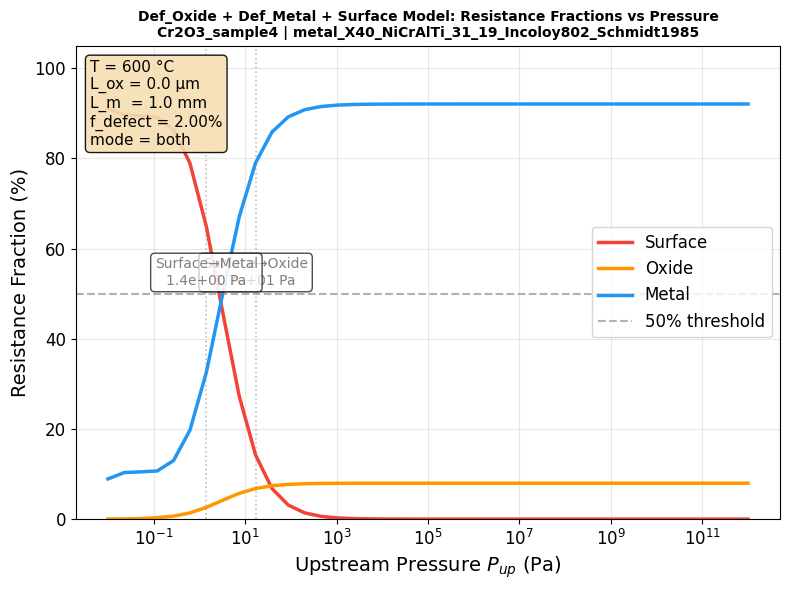

In [7]:
# =============================================================================
# SECTION 1 | CELL 5 — PLOT [C]: Resistance Fractions vs Pressure
# Question: Which layer controls transport and at what pressure does
#           control switch between surface, oxide, and metal?
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

valid_res = valid_P & np.isfinite(frac_surface_arr)

ax.semilogx(
    P_ARR[valid_res], frac_surface_arr[valid_res] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface'
)
ax.semilogx(
    P_ARR[valid_res], frac_oxide_arr[valid_res] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide'
)
ax.semilogx(
    P_ARR[valid_res], frac_metal_arr[valid_res] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label='Metal'
)

# ── 50% threshold line ────────────────────────────────────────────────────────
ax.axhline(50, color='gray', ls='--', lw=1.5, alpha=0.6, label='50% threshold')

# ── Crossover annotations ─────────────────────────────────────────────────────
for label, frac_a, frac_b, color_a in [
    ('Surface→Oxide', frac_surface_arr, frac_oxide_arr,
     CURVE_STYLES['surface_region']['color']),
    ('Surface→Metal', frac_surface_arr, frac_metal_arr,
     CURVE_STYLES['metal_region']['color']),
    ('Oxide→Metal',   frac_oxide_arr,   frac_metal_arr,
     CURVE_STYLES['oxide_region']['color']),
]:
    diff = frac_a[valid_res] - frac_b[valid_res]
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    for idx in sign_changes:
        P_cross = P_ARR[valid_res][idx]
        ax.axvline(P_cross, color='gray', ls=':', lw=1.2, alpha=0.5)
        ax.text(
            P_cross, 52,
            f'{label}\n{P_cross:.1e} Pa',
            fontsize=STYLE['fontsize_annotation'] - 1,
            ha='center', color='gray',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )

# ── Operating conditions box ──────────────────────────────────────────────────
total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}"
)
ax.text(
    0.02, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Def_Oxide + Def_Metal + Surface Model: Resistance Fractions vs Pressure\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [8]:
# =============================================================================
# SECTION 1 | CELL 7 — TABLE [C]: Resistance Fractions vs Pressure
# =============================================================================

valid_res = valid_P & np.isfinite(frac_surface_arr)

df_C = pd.DataFrame({
    'P_up (Pa)':            P_ARR[valid_res],
    'J_total (mol/m²/s)':   J_arr[valid_res],
    'frac_surface (%)':     frac_surface_arr[valid_res] * 100,
    'frac_oxide (%)':       frac_oxide_arr[valid_res]   * 100,
    'frac_metal (%)':       frac_metal_arr[valid_res]   * 100,
    'system_rate_limiting': rate_lim_arr[valid_res],
    'dominant_path':        dominant_path_arr[valid_res],
})

df_C['dominant_layer'] = df_C[
    ['frac_surface (%)', 'frac_oxide (%)', 'frac_metal (%)']
].idxmax(axis=1).str.replace('frac_', '').str.replace(' (%)', '')

# Format
df_C_display = df_C.copy()
df_C_display['P_up (Pa)']          = df_C_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_C_display['J_total (mol/m²/s)'] = df_C_display['J_total (mol/m²/s)'].apply(lambda x: f'{x:.4e}')
for col in ['frac_surface (%)', 'frac_oxide (%)', 'frac_metal (%)']:
    df_C_display[col] = df_C_display[col].round(2)

print("=" * 60)
print(f"TABLE [C]: Resistance Fractions  |  T = {T_op-273.15:.0f} °C  |  {valid_res.sum()} points")
print("=" * 60)
display(df_C_display)

print("\n  Dominant layer counts:")
for layer in ['surface', 'oxide', 'metal']:
    n = (df_C['dominant_layer'] == layer).sum()
    if n > 0:
        print(f"    {layer:<10} : {n} pts")

TABLE [C]: Resistance Fractions  |  T = 600 °C  |  40 points


,P_up (Pa),J_total (mol/m²/s),frac_surface (%),frac_oxide (%),frac_metal (%),system_rate_limiting,dominant_path,dominant_layer
0,1.000e-02,3.0247e-11,91.07,0.02,8.91,surface,intact,surface
1,2.285e-02,6.4057e-11,89.63,0.05,10.32,surface,intact,surface
2,5.223e-02,1.3807e-10,89.39,0.13,10.48,surface,intact,surface
3,1.194e-01,3.0105e-10,89.03,0.30,10.67,surface,intact,surface
4,2.728e-01,6.5813e-10,86.35,0.66,12.99,surface,intact,surface
5,6.236e-01,1.4237e-09,78.88,1.38,19.73,surface,intact,surface
6,1.425e+00,2.9923e-09,64.84,2.60,32.56,surface,intact,surface
7,3.257e+00,5.9896e-09,45.75,4.19,50.06,mixed,intact,metal
8,7.444e+00,1.1280e-08,27.28,5.71,67.01,metal,intact,metal
9,1.701e+01,2.0011e-08,14.18,6.79,79.03,metal,intact,metal



  Dominant layer counts:
    surface    : 7 pts
    metal      : 33 pts


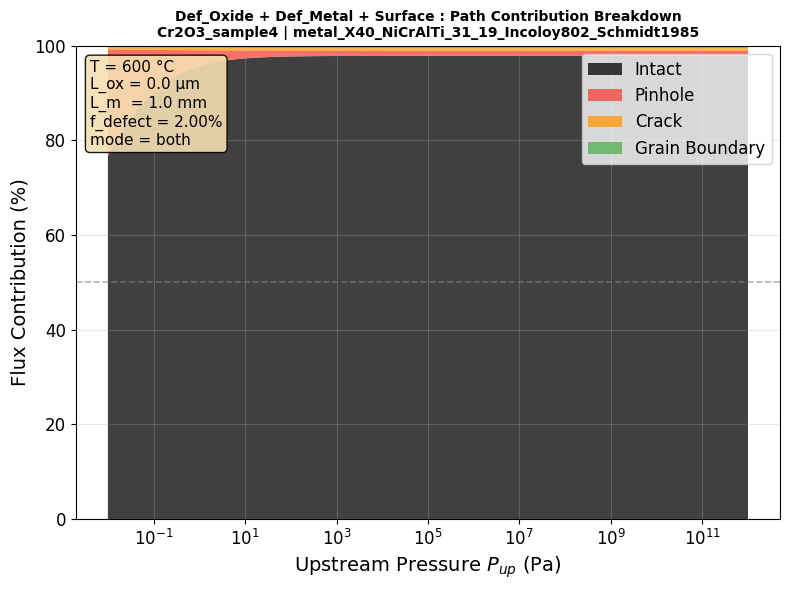

In [9]:
# =============================================================================
# SECTION 1 | CELL 6 — PLOT [E]: Path Contribution Breakdown
# Question: Which oxide path carries the flux — intact oxide or which
#           defect type — and how does dominance shift with pressure?
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

valid_path = valid_P & np.isfinite(frac_intact_arr)
P_v = P_ARR[valid_path]

# ── Collect active fractions ──────────────────────────────────────────────────
fracs = []
if np.any(np.isfinite(frac_intact_arr[valid_path])):
    fracs.append(('Intact',         frac_intact_arr[valid_path]  * 100,
                  CURVE_STYLES['intact']['color']))
if 'pinhole' in defect_config and np.any(np.isfinite(frac_pinhole_arr[valid_path])):
    fracs.append(('Pinhole',        frac_pinhole_arr[valid_path] * 100,
                  CURVE_STYLES['pinhole']['color']))
if 'crack' in defect_config and np.any(np.isfinite(frac_crack_arr[valid_path])):
    fracs.append(('Crack',          frac_crack_arr[valid_path]   * 100,
                  CURVE_STYLES['crack']['color']))
if 'grain_boundary' in defect_config and np.any(np.isfinite(frac_gb_arr[valid_path])):
    fracs.append(('Grain Boundary', frac_gb_arr[valid_path]      * 100,
                  CURVE_STYLES['gb']['color']))

# ── Stacked area ──────────────────────────────────────────────────────────────
labels  = [f[0] for f in fracs]
colors  = [f[2] for f in fracs]
data    = np.nan_to_num([f[1] for f in fracs], nan=0.0)

ax.stackplot(P_v, data, labels=labels, colors=colors, alpha=0.75)

# ── Intact → defect crossover annotation ─────────────────────────────────────
if len(fracs) > 1:
    intact_frac = np.nan_to_num(frac_intact_arr[valid_path] * 100, nan=100.0)
    defect_frac = 100 - intact_frac
    diff        = intact_frac - defect_frac
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    for idx in sign_changes:
        P_cross = P_v[idx]
        ax.axvline(P_cross, color='black', ls='--', lw=1.5, alpha=0.7)
        ax.text(
            P_cross, 52,
            f'Intact→Defect\n{P_cross:.1e} Pa',
            fontsize=STYLE['fontsize_annotation'] - 1,
            ha='center', color='black',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# ── 50% threshold line ────────────────────────────────────────────────────────
ax.axhline(50, color='gray', ls='--', lw=1.2, alpha=0.6)

# ── Operating conditions box ──────────────────────────────────────────────────
total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}"
)
ax.text(
    0.02, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xscale('log')
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux Contribution (%)',            fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Def_Oxide + Def_Metal + Surface : Path Contribution Breakdown\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 100)
ax.legend(fontsize=STYLE['fontsize_legend'], loc='upper right')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [10]:
# =============================================================================
# SECTION 1 | CELL 9 — TABLE [E]: Path Contribution Breakdown
# =============================================================================

valid_path = valid_P & np.isfinite(frac_intact_arr)

df_E = pd.DataFrame({
    'P_up (Pa)':            P_ARR[valid_path],
    'J_total (mol/m²/s)':   J_arr[valid_path],
    'intact (%)':           np.nan_to_num(frac_intact_arr[valid_path]  * 100),
    'pinhole (%)':          np.nan_to_num(frac_pinhole_arr[valid_path] * 100),
    'crack (%)':            np.nan_to_num(frac_crack_arr[valid_path]   * 100),
    'grain_boundary (%)':   np.nan_to_num(frac_gb_arr[valid_path]      * 100),
    'J_intact':             J_intact_arr[valid_path],
    'J_pinhole':            J_pinhole_arr[valid_path],
    'J_crack':              J_crack_arr[valid_path],
    'J_grain_boundary':     J_gb_arr[valid_path],
    'enhancement_factor':   enhancement_arr[valid_path],
})

path_cols = ['intact (%)', 'pinhole (%)', 'crack (%)', 'grain_boundary (%)']
df_E['dominant_path'] = df_E[path_cols].idxmax(axis=1).str.replace(' (%)', '')

# Format
df_E_display = df_E.copy()
df_E_display['P_up (Pa)'] = df_E_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
float_sci_E = ['J_total (mol/m²/s)', 'J_intact', 'J_pinhole',
               'J_crack', 'J_grain_boundary']
for col in float_sci_E:
    df_E_display[col] = df_E_display[col].apply(
        lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
    )
for col in path_cols:
    df_E_display[col] = df_E_display[col].round(2)
df_E_display['enhancement_factor'] = df_E_display['enhancement_factor'].round(4)

print("=" * 60)
print(f"TABLE [E]: Path Contributions  |  T = {T_op-273.15:.0f} °C  |  {valid_path.sum()} points")
print("=" * 60)
display(df_E_display)

print("\n  Dominant path counts:")
for path in ['intact', 'pinhole', 'crack', 'grain_boundary']:
    n = (df_E['dominant_path'] == path).sum()
    if n > 0:
        print(f"    {path:<16} : {n} pts")

TABLE [E]: Path Contributions  |  T = 600 °C  |  40 points


,P_up (Pa),J_total (mol/m²/s),intact (%),pinhole (%),crack (%),grain_boundary (%),J_intact,J_pinhole,J_crack,J_grain_boundary,enhancement_factor,dominant_path
0,1.000e-02,3.0247e-11,76.70,22.52,0.39,0.39,2.3673e-11,6.8105e-10,2.3677e-11,2.3677e-11,1.2777,intact
1,2.285e-02,6.4057e-11,82.64,16.51,0.42,0.42,5.4019e-11,1.0578e-09,5.4040e-11,5.4040e-11,1.1858,intact
2,5.223e-02,1.3807e-10,87.32,11.79,0.45,0.45,1.2302e-10,1.6280e-09,1.2313e-10,1.2313e-10,1.1223,intact
3,1.194e-01,3.0105e-10,90.80,8.27,0.46,0.46,2.7893e-10,2.4905e-09,2.7949e-10,2.7949e-10,1.0793,intact
4,2.728e-01,6.5813e-10,93.28,5.77,0.48,0.48,6.2642e-10,3.7947e-09,6.2912e-10,6.2912e-10,1.0506,intact
5,6.236e-01,1.4237e-09,94.97,4.05,0.49,0.49,1.3797e-09,5.7666e-09,1.3920e-09,1.3920e-09,1.0319,intact
6,1.425e+00,2.9923e-09,96.08,2.92,0.50,0.50,2.9337e-09,8.7478e-09,2.9833e-09,2.9833e-09,1.0200,intact
7,3.257e+00,5.9896e-09,96.77,2.21,0.51,0.51,5.9146e-09,1.3255e-08,6.0807e-09,6.0807e-09,1.0127,intact
8,7.444e+00,1.1280e-08,97.19,1.78,0.52,0.52,1.1186e-08,2.0068e-08,1.1639e-08,1.1639e-08,1.0083,intact
9,1.701e+01,2.0011e-08,97.44,1.52,0.52,0.52,1.9896e-08,3.0369e-08,2.0921e-08,2.0921e-08,1.0058,intact



  Dominant path counts:
    intact           : 40 pts


  ⚠  surface: no surface-dominated pressure found — skipped
  ⚠  oxide: no oxide-dominated pressure found — skipped
  ⚠  metal: no metal-dominated pressure found — skipped


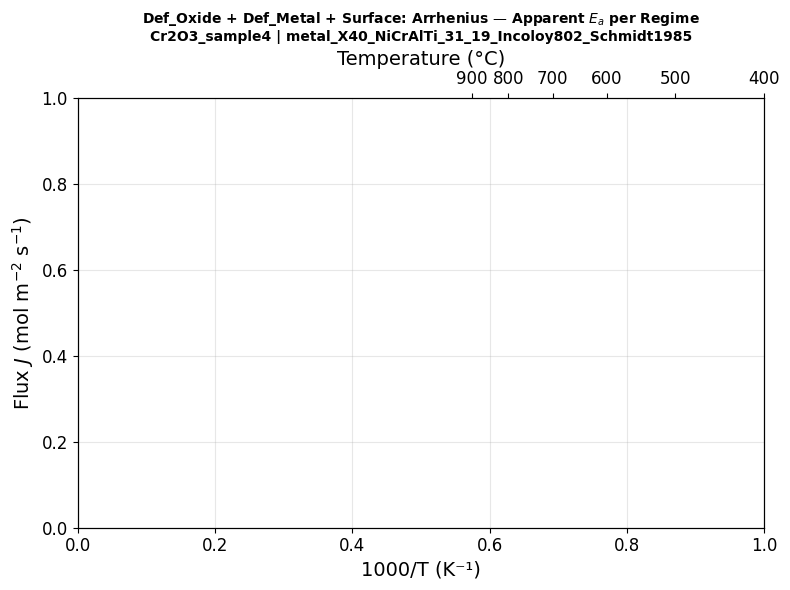

In [11]:
# =============================================================================
# SECTION 1 | CELL 7 — PLOT [F]: Arrhenius — Apparent Ea per Regime
# Question: What is the apparent activation energy in each rate-limiting
#           regime, and does it match the expected value from config?
# =============================================================================
from scipy import stats

# ── Reference activation energies from config ─────────────────────────────────
E_REF_SURFACE = SK_OX['E_diss']                        # J/mol
E_REF_OXIDE   = OXIDE['E_D_ox'] + OXIDE['H_sol_ox']   # J/mol
E_REF_METAL   = METAL['E_D']    + METAL['H_s']        # J/mol

# # ── Pick one representative pressure per regime from the pressure sweep ───────
# def pick_regime_pressure(regime_str):
#     """Return mid-range P where that regime dominates, or None."""
#     mask = (rate_lim_arr == regime_str) & valid_P
#     if not np.any(mask):
#         return None
#     idxs = np.where(mask)[0]
#     return P_ARR[idxs[len(idxs) // 2]]

# P_for_surface_Ea = pick_regime_pressure('surface')
# P_for_oxide_Ea   = pick_regime_pressure('oxide')
# P_for_metal_Ea   = pick_regime_pressure('metal')

P_for_surface_Ea = np.median(P_ARR[(frac_surface_arr > 0.95) & valid_P]) \
                   if np.sum((frac_surface_arr > 0.95) & valid_P) > 3 else None
P_for_oxide_Ea   = np.median(P_ARR[(frac_oxide_arr   > 0.95) & valid_P]) \
                   if np.sum((frac_oxide_arr   > 0.95) & valid_P) > 3 else None
P_for_metal_Ea   = np.median(P_ARR[(frac_metal_arr   > 0.95) & valid_P]) \
                   if np.sum((frac_metal_arr   > 0.95) & valid_P) > 3 else None

# ── Regime classifier ─────────────────────────────────────────────────────────
def classify_regime(fs, fo, fm, pure_thresh=0.95, mixed_thresh=0.50):
    if   fs >= pure_thresh:  return 'pure_surface'
    elif fo >= pure_thresh:  return 'pure_oxide'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'], 'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'], 'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_oxide':    {'color': CURVE_STYLES['oxide_region']['color'],   'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide':   {'color': CURVE_STYLES['oxide_region']['color'],   'marker': 's', 'ms': 5,  'alpha': 0.35},
    'pure_metal':    {'color': CURVE_STYLES['metal_region']['color'],   'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal':   {'color': CURVE_STYLES['metal_region']['color'],   'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],   'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

# ── Arrhenius sweep per regime ────────────────────────────────────────────────
regime_cases = [
    ('surface', P_for_surface_Ea, E_REF_SURFACE, 'E_diss'),
    ('oxide',   P_for_oxide_Ea,   E_REF_OXIDE,   'E_D_ox + H_sol'),
    ('metal',   P_for_metal_Ea,   E_REF_METAL,   'E_D + H_s'),
]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plotted_cls_labels = set()
arrhenius_results  = {}

for label, P_fixed, E_ref, E_name in regime_cases:
    if P_fixed is None:
        print(f"  ⚠  {label}: no {label}-dominated pressure found — skipped")
        arrhenius_results[label] = None
        continue

    J_T_arr   = np.full(len(T_ARR), np.nan)
    class_arr = np.empty(len(T_ARR), dtype=object)

    for j, T_K in enumerate(T_ARR):
        try:
            r = run_full_model(P_fixed, T_K)
            J_T_arr[j] = r['J_total']
            rs = r.get('flux_weighted_resistances')
            if rs is not None:
                class_arr[j] = classify_regime(
                    rs['fraction_surface'],
                    rs['fraction_oxide'],
                    rs['fraction_metal'],
                )
            else:
                class_arr[j] = 'mixed'
        except Exception:
            class_arr[j] = 'mixed'

    # Plot all classified points
    inv_T = 1000.0 / T_ARR
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & np.isfinite(J_T_arr) & (J_T_arr > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax.semilogy(
            inv_T[mask], J_T_arr[mask],
            ls='none', color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_cls_labels else '_nolegend_'
        )
        plotted_cls_labels.add(cls_label)

    # Fit pure points only
    pure = (class_arr == f'pure_{label}') & np.isfinite(J_T_arr) & (J_T_arr > 0)
    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points — fit skipped")
        arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_T_arr[pure])
    )
    E_a = -slope * R * 1000   # R in J/mol/K, inv_T in 1000/K

    ax.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=CURVE_STYLES[f'{label}_region']['color'],
        ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label} (pure pts)'
    )

    arrhenius_results[label] = {
        'E_a': E_a, 'E_ref': E_ref, 'E_name': E_name,
        'r_sq': r_val**2, 'n_pure': int(np.sum(pure)),
        'T_range': (T_ARR[pure].min() - 273.15, T_ARR[pure].max() - 273.15),
        'P_fixed': P_fixed,
    }

# ── Dual x-axis (°C on top) ───────────────────────────────────────────────────
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= CONDITIONS['T_range'][0]) & (T_ticks_K <= CONDITIONS['T_range'][1])
if np.any(in_range):
    ax_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_top.tick_params(labelsize=STYLE['fontsize_tick'])

# ── Annotation box: extracted vs expected ────────────────────────────────────
annot = []
for label, _, E_ref, E_name in regime_cases:
    res = arrhenius_results.get(label)
    if res is None:
        annot.append(f'{label.capitalize()}: not extractable')
        annot.append(f'  Expected ({E_name}): {E_ref/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_ref) < 3000
        annot.append(f'{label.capitalize()}-limited:')
        annot.append(f'  Extracted : {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected  : {E_ref/1000:.1f} kJ/mol  ({E_name})')
        annot.append(f'  R² = {res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_range"][0]:.0f}–{res["T_range"][1]:.0f} °C  ({res["n_pure"]} pts)')
    annot.append('')

# ax.text(
#     0.97, 0.57, '\n'.join(annot).rstrip(),
#     transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'] - 1,
#     va='top', ha='right',
#     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
# )

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('1000/T (K⁻¹)',                   fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)', fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Def_Oxide + Def_Metal + Surface: Arrhenius — Apparent $E_a$ per Regime\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
# ax.legend(fontsize=STYLE['fontsize_legend'] - 2, loc='lower left',
#           ncol=2, title='Symbol size = purity')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# SECTION 1 | CELL 11 — TABLE [F]: Arrhenius
# Table (i): raw T sweep per regime  |  Table (ii): fit summary
# =============================================================================

# ── Table (i): Raw T sweep data ───────────────────────────────────────────────
rows_F_raw = []
for label, P_fixed, E_ref, E_name in regime_cases:
    if P_fixed is None:
        continue
    J_T_arr   = np.full(len(T_ARR), np.nan)
    class_arr = np.empty(len(T_ARR), dtype=object)
    for j, T_K in enumerate(T_ARR):
        try:
            r = run_full_model(P_fixed, T_K)
            J_T_arr[j] = r['J_total']
            rs = r.get('flux_weighted_resistances')
            class_arr[j] = classify_regime(
                rs['fraction_surface'], rs['fraction_oxide'], rs['fraction_metal']
            ) if rs is not None else 'mixed'
        except Exception:
            class_arr[j] = 'error'
    for j, T_K in enumerate(T_ARR):
        rows_F_raw.append({
            'regime':          label,
            'P_fixed (Pa)':    P_fixed,
            'T (K)':           T_K,
            'T (°C)':          round(T_K - 273.15, 1),
            '1000/T (K⁻¹)':   round(1000 / T_K, 4),
            'J (mol/m²/s)':    J_T_arr[j],
            'regime_class':    class_arr[j],
        })

df_F_raw = pd.DataFrame(rows_F_raw)
df_F_raw_display = df_F_raw.copy()
df_F_raw_display['P_fixed (Pa)'] = df_F_raw_display['P_fixed (Pa)'].apply(lambda x: f'{x:.3e}')
df_F_raw_display['J (mol/m²/s)'] = df_F_raw_display['J (mol/m²/s)'].apply(
    lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
)

print("=" * 60)
print("TABLE [F-i]: Arrhenius Raw T Sweep")
print("=" * 60)
display(df_F_raw_display)

# ── Table (ii): Fit summary ───────────────────────────────────────────────────
rows_F_summary = []
for label, _, E_ref, E_name in regime_cases:
    res = arrhenius_results.get(label)
    P_fixed = (P_for_surface_Ea if label == 'surface'
               else P_for_oxide_Ea if label == 'oxide'
               else P_for_metal_Ea)
    if res is None:
        rows_F_summary.append({
            'regime':                 label,
            'P_fixed (Pa)':           P_fixed,
            'E_a extracted (kJ/mol)': np.nan,
            'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
            'E_name':                 E_name,
            'delta (kJ/mol)':         np.nan,
            'R²':                     np.nan,
            'n_pure_pts':             0,
            'T_min (°C)':             np.nan,
            'T_max (°C)':             np.nan,
            'match':                  '—',
        })
    else:
        delta = res['E_a'] - E_ref
        rows_F_summary.append({
            'regime':                 label,
            'P_fixed (Pa)':           res['P_fixed'],
            'E_a extracted (kJ/mol)': round(res['E_a'] / 1000, 2),
            'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
            'E_name':                 E_name,
            'delta (kJ/mol)':         round(delta / 1000, 2),
            'R²':                     round(res['r_sq'], 4),
            'n_pure_pts':             res['n_pure'],
            'T_min (°C)':             round(res['T_range'][0], 1),
            'T_max (°C)':             round(res['T_range'][1], 1),
            'match':                  '✓' if abs(delta) < 3000 else '⚠',
        })

df_F_summary = pd.DataFrame(rows_F_summary)
df_F_summary['P_fixed (Pa)'] = df_F_summary['P_fixed (Pa)'].apply(
    lambda x: f'{x:.3e}' if pd.notna(x) else '—'
)

print("\n" + "=" * 60)
print("TABLE [F-ii]: Arrhenius Fit Summary")
print("=" * 60)
display(df_F_summary)

KeyError: 'P_fixed (Pa)'

In [ ]:
# =============================================================================
# SECTION 1 | CELL 8 — PLOT [H]: Rate-Limiting Map vs Temperature
# Question: How does temperature shift the pressure at which surface
#           kinetics stop being rate-limiting?
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

T_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_5)))
crossover_pressures = []

for j, (T_K, col) in enumerate(zip(T_5, T_colors)):
    fs_row   = frac_surface_5T[j] * 100
    valid_row = np.isfinite(fs_row)
    if not np.any(valid_row):
        continue

    ax.semilogx(
        P_ARR[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f} °C'
    )

    # Crossover: surface fraction crosses 50%
    diff = fs_row[valid_row] - 50
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) > 0:
        idx = sc[0]
        fs_v = fs_row[valid_row]
        if fs_v[idx] > 50 and fs_v[idx + 1] < 50:
            crossover_pressures.append((T_K, P_ARR[valid_row][idx]))

# ── 50% threshold line ────────────────────────────────────────────────────────
ax.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

# ── Crossover annotation ──────────────────────────────────────────────────────
if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]
    direction = 'lower P as T ↑' if P_co_high < P_co_low else 'higher P as T ↑'
    ax.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n'
        f'E_diss = {E_REF_SURFACE/1000:.0f} kJ/mol\n'
        f'E_D + H_s = {E_REF_METAL/1000:.0f} kJ/mol',
        transform=ax.transAxes,
        fontsize=STYLE['fontsize_annotation'] - 1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    n_surface = np.sum(rate_lim_arr == 'surface')
    dominant  = 'surface-limited' if n_surface > len(P_ARR) // 2 else 'bulk-limited'
    ax.text(
        0.05, 0.05,
        f'No crossover found at any T\nSystem is {dominant}',
        transform=ax.transAxes,
        fontsize=STYLE['fontsize_annotation'] - 1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=plt.Normalize(vmin=T_5[0] - 273.15, vmax=T_5[-1] - 273.15)
)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Temperature (°C)')

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',   fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Surface Resistance Fraction (%)',   fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Def_Oxide + Def_Metal + Surface: Rate-Limiting Map vs Temperature\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.legend(fontsize=STYLE['fontsize_legend'] - 1, loc='upper right', title='Temperature')
ax.grid(True, alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

# ── Summary print ─────────────────────────────────────────────────────────────
print("=" * 60)
print("PLOT [H] SUMMARY")
print("=" * 60)
if crossover_pressures:
    for T_K, P_co in crossover_pressures:
        print(f"  T = {T_K-273.15:.0f} °C  →  P_crossover = {P_co:.2e} Pa")
else:
    print("  No surface→bulk crossover detected across T range")
print("=" * 60)

In [ ]:
# =============================================================================
# SECTION 1 | CELL 12 — TABLE [H]: Rate-Limiting Map vs Temperature
# =============================================================================

rows_H = []
for j, T_K in enumerate(T_5):
    fs_row    = frac_surface_5T[j] * 100
    fo_row    = frac_oxide_5T[j]   * 100
    fm_row    = frac_metal_5T[j]   * 100
    valid_row = np.isfinite(fs_row)
    if not np.any(valid_row):
        continue

    diff = fs_row[valid_row] - 50
    sc   = np.where(np.diff(np.sign(diff)))[0]
    P_co = P_ARR[valid_row][sc[0]] if len(sc) > 0 else np.nan

    for i, P in enumerate(P_ARR[valid_row]):
        fs = fs_row[valid_row][i]
        fo = fo_row[valid_row][i]
        fm = fm_row[valid_row][i]
        rows_H.append({
            'T (K)':             T_K,
            'T (°C)':            round(T_K - 273.15, 1),
            'P_up (Pa)':         P,
            'frac_surface (%)':  round(fs, 2),
            'frac_oxide (%)':    round(fo, 2),
            'frac_metal (%)':    round(fm, 2),
            'dominant_layer':    'surface' if fs == max(fs, fo, fm)
                                 else 'oxide' if fo == max(fs, fo, fm)
                                 else 'metal',
            'crossover_P (Pa)':  P_co,
        })

df_H = pd.DataFrame(rows_H)

# ── Sampled display: N rows per temperature ───────────────────────────────────
N_ROWS_PER_T = 10   # adjust as needed

rows_display = []
for T_K in T_5:
    subset = df_H[df_H['T (K)'] == T_K].reset_index(drop=True)
    if len(subset) == 0:
        continue
    # Always include first, last, and crossover row + evenly spaced rest
    n      = len(subset)
    idxs   = np.linspace(0, n - 1, N_ROWS_PER_T, dtype=int)
    # Add crossover index if it exists
    P_co   = subset['crossover_P (Pa)'].iloc[0]
    if np.isfinite(P_co):
        co_idx = (subset['P_up (Pa)'] - P_co).abs().idxmin()
        idxs   = np.unique(np.append(idxs, co_idx))
    rows_display.append(subset.iloc[idxs])

df_H_sampled = pd.concat(rows_display).reset_index(drop=True)

# Format
df_H_display = df_H_sampled.copy()
df_H_display['P_up (Pa)']        = df_H_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_H_display['crossover_P (Pa)'] = df_H_display['crossover_P (Pa)'].apply(
    lambda x: f'{x:.3e}' if np.isfinite(x) else '—'
)

print("=" * 60)
print(f"TABLE [H]: Rate-Limiting Map vs Temperature  ({N_ROWS_PER_T} rows/T)")
print("=" * 60)
display(df_H_display)

# Crossover summary
print("\n  Crossover pressures:")
df_H_co = df_H.drop_duplicates('T (°C)')[['T (°C)', 'crossover_P (Pa)']].copy()
df_H_co['crossover_P (Pa)'] = df_H_co['crossover_P (Pa)'].apply(
    lambda x: f'{x:.3e}' if np.isfinite(x) else '—'
)
display(df_H_co)


## Section 2 — L3+L4+L6: Surface Kinetics Non-Rate-Limiting

### Approach

Same **L3+L4+L6 code path** as Section 1. No model change. Instead, the
surface kinetic parameters are overwritten so that the surface dissociation
step is never the bottleneck — surface kinetics are made infinitely fast
on **all paths**.

Two targeted changes:

| Path | Surface Kinetics | Section 1 | Section 2 | Method |
|------|-----------------|-----------|-----------|--------|
| Intact, Crack, GB | Oxide surface (`SK_OX`) | Physical Arrhenius | `k_diss × 1e10`, `K_eq × 1e10` | Redefine helpers |
| Pinhole | Metal surface (`SK_M`) | Physical Arrhenius | Sieverts equilibrium assumed | `use_sieverts_pinhole = True` |

### Physical Interpretation

- **Oxide surface (intact/crack/GB paths):** When `k_diss → ∞`, surface
coverage $\theta$ is always at Langmuir equilibrium instantly. Surface
resistance → 0. Transport is controlled entirely by oxide and metal bulk.

- **Pinhole path:** Setting `use_sieverts_pinhole = True` bypasses the
metal surface kinetic step entirely. The solver assumes $C_{surface} = K_s \sqrt{P}$
directly — the Sieverts limit. This is the physically correct way to
express infinitely fast surface kinetics on bare metal.

### What to look for vs Section 1

- **Plot [A]:** Does flux increase? By how much and at which pressures?
- **Plot [C]:** Surface fraction should collapse to ~0 across all pressures
- **Plot [E]:** Path breakdown unaffected — defect geometry unchanged
- **Plot [F]:** Apparent $E_a$ should shift — surface $E_a$ disappears, oxide or metal dominates
- **Plot [H]:** No surface-dominated region should appear at any T

---

In [ ]:
# =============================================================================
# SECTION 2 | CELL 1 — PARAMETER OVERWRITE
# Surface kinetics made non-rate-limiting on all paths.
# Everything else (geometry, oxide, metal bulk, defects) unchanged.
# =============================================================================

# ── Capture Section 1 values at T_op for before/after print ──────────────────
k_diss_S1        = get_k_diss_at_T(T_op)
K_eq_S1          = get_K_eq_at_T(T_op)
k_recomb_S1      = k_diss_S1 / K_eq_S1
k_diss_metal_S1  = get_k_diss_metal_at_T(T_op)
K_eq_metal_S1    = get_K_eq_metal_at_T(T_op)
k_recomb_metal_S1= k_diss_metal_S1 / K_eq_metal_S1

# ── Overwrite 1: Oxide surface helpers (intact / crack / GB paths) ────────────
_k_diss_S1_ref  = SK_OX['k_diss_ref']
_K_eq_S1_ref    = SK_OX['K_eq_ref']
_E_diss_S1      = SK_OX['E_diss']
_H_eq_S1        = SK_OX['H_eq']
_T_ref_ox       = SK_OX['T_ref']

def get_k_diss_at_T(T):
    base = _k_diss_S1_ref * np.exp((-_E_diss_S1 / R) * (1/T - 1/_T_ref_ox))
    return base ** 0  # Set to constant (non-rate-limiting) by raising to zero power

def get_K_eq_at_T(T):
    base = _K_eq_S1_ref * np.exp((-_H_eq_S1 / R) * (1/T - 1/_T_ref_ox))
    return base ** 0  # Set to constant (non-rate-limiting) by raising to zero power



# # ── Capture true Section 1 values directly from config ───────────────────────
# _inv_T_diff = 1/T_op - 1/SK_OX['T_ref']
# k_diss_S1   = SK_OX['k_diss_ref'] * np.exp((-SK_OX['E_diss']  / R) * _inv_T_diff)
# K_eq_S1     = SK_OX['K_eq_ref']   * np.exp((-SK_OX['H_eq']    / R) * _inv_T_diff)
# k_recomb_S1 = k_diss_S1 / K_eq_S1

# _inv_T_diff_m  = 1/T_op - 1/SK_M['T_ref']
# k_diss_metal_S1  = SK_M['k_diss_metal_ref'] * np.exp((-SK_M['E_diss_metal'] / R) * _inv_T_diff_m)
# K_eq_metal_S1    = SK_M['K_eq_metal_ref']   * np.exp((-SK_M['H_eq_metal']   / R) * _inv_T_diff_m)
# k_recomb_metal_S1= k_diss_metal_S1 / K_eq_metal_S1



# ── Overwrite 2: Pinhole path — Sieverts limit ────────────────────────────────
use_sieverts_pinhole = True
k_diss_metal_arg     = None
K_eq_metal_arg       = None

# ── Capture Section 2 values at T_op for verification ────────────────────────
k_diss_S2        = get_k_diss_at_T(T_op)
K_eq_S2          = get_K_eq_at_T(T_op)
k_recomb_S2      = k_diss_S2 / K_eq_S2

# ── Before / After comparison print ──────────────────────────────────────────
print("=" * 65)
print("SECTION 2 — PARAMETER OVERWRITE SUMMARY")
print("=" * 65)

print(f"\n  Oxide surface (intact / crack / GB paths)")
print(f"  {'Parameter':<14} {'Section 1':>18} {'Section 2':>18} {'Ratio':>12}")
print(f"  {'-'*62}")
print(f"  {'k_diss':<14} {k_diss_S1:>18.4e} {k_diss_S2:>18.4e} {k_diss_S2/k_diss_S1:>12.2e}")
print(f"  {'K_eq':<14} {K_eq_S1:>18.4e} {K_eq_S2:>18.4e} {K_eq_S2/K_eq_S1:>12.2e}")
print(f"  {'k_recomb':<14} {k_recomb_S1:>18.4e} {k_recomb_S2:>18.4e} {k_recomb_S2/k_recomb_S1:>12.2e}")

print(f"\n  Pinhole path (metal surface)")
print(f"  {'Parameter':<14} {'Section 1':>18} {'Section 2':>18}")
print(f"  {'-'*62}")
print(f"  {'k_diss_metal':<14} {k_diss_metal_S1:>18.4e} {'— (Sieverts)':>18}")
print(f"  {'K_eq_metal':<14} {K_eq_metal_S1:>18.4e} {'— (Sieverts)':>18}")
print(f"  {'k_recomb_m':<14} {k_recomb_metal_S1:>18.4e} {'— (Sieverts)':>18}")
print(f"  use_sieverts_pinhole : {use_sieverts_pinhole}")

print(f"\n  Unchanged parameters")
print(f"    SIM config     : {METAL_KEY} | {OXIDE_KEY}")
print(f"    T_op           : {T_op-273.15:.0f} °C  ({T_op} K)")
print(f"    L_ox           : {L_ox*1e6:.1f} μm")
print(f"    L_m            : {L_m*1e3:.1f} mm")
print(f"    mode           : {mode}")
print(f"    defect_config  : {list(defect_config.keys())}")
print(f"    microstructure : grain_size = {grain_size*1e6:.1f} μm")
print("=" * 65)

In [ ]:
# =============================================================================
# SECTION 2 | CELL 2 — COMPUTE
# Identical structure to Cell 1.3. All arrays prefixed S2_.
# Uses overwritten helpers from Cell 2.1 automatically via run_full_model.
# =============================================================================

# ── (i) Pressure sweep at T_op ────────────────────────────────────────────────
n_P = len(P_ARR)

S2_J_arr            = np.full(n_P, np.nan)
S2_frac_surface_arr = np.full(n_P, np.nan)
S2_frac_oxide_arr   = np.full(n_P, np.nan)
S2_frac_metal_arr   = np.full(n_P, np.nan)
S2_frac_intact_arr  = np.full(n_P, np.nan)
S2_frac_pinhole_arr = np.full(n_P, np.nan)
S2_frac_crack_arr   = np.full(n_P, np.nan)
S2_frac_gb_arr      = np.full(n_P, np.nan)
S2_J_intact_arr     = np.full(n_P, np.nan)
S2_J_pinhole_arr    = np.full(n_P, np.nan)
S2_J_crack_arr      = np.full(n_P, np.nan)
S2_J_gb_arr         = np.full(n_P, np.nan)
S2_enhancement_arr  = np.full(n_P, np.nan)
S2_D_eff_avg_arr    = np.full(n_P, np.nan)
S2_rate_lim_arr     = np.empty(n_P, dtype=object)
S2_dominant_path_arr= np.empty(n_P, dtype=object)

for i, P in enumerate(P_ARR):
    try:
        r  = run_full_model(P, T_op)
        fb = r['flux_breakdown']
        rs = r.get('flux_weighted_resistances')

        S2_J_arr[i]             = r['J_total']
        S2_enhancement_arr[i]   = r.get('enhancement_vs_intact', np.nan)
        S2_D_eff_avg_arr[i]     = r.get('D_eff_avg', np.nan)
        S2_dominant_path_arr[i] = r.get('dominant_path', 'unknown')
        S2_rate_lim_arr[i]      = r.get('system_rate_limiting', 'unknown')

        S2_frac_intact_arr[i]   = fb.get('intact',        {}).get('fraction_of_total', np.nan)
        S2_frac_pinhole_arr[i]  = fb.get('pinhole',        {}).get('fraction_of_total', np.nan)
        S2_frac_crack_arr[i]    = fb.get('crack',          {}).get('fraction_of_total', np.nan)
        S2_frac_gb_arr[i]       = fb.get('grain_boundary', {}).get('fraction_of_total', np.nan)

        S2_J_intact_arr[i]      = fb.get('intact',        {}).get('flux', np.nan)
        S2_J_pinhole_arr[i]     = fb.get('pinhole',        {}).get('flux', np.nan)
        S2_J_crack_arr[i]       = fb.get('crack',          {}).get('flux', np.nan)
        S2_J_gb_arr[i]          = fb.get('grain_boundary', {}).get('flux', np.nan)

        if rs is not None:
            S2_frac_surface_arr[i] = rs['fraction_surface']
            S2_frac_oxide_arr[i]   = rs['fraction_oxide']
            S2_frac_metal_arr[i]   = rs['fraction_metal']

    except Exception as e:
        S2_rate_lim_arr[i]      = 'error'
        S2_dominant_path_arr[i] = 'error'

S2_valid_P = np.isfinite(S2_J_arr) & (S2_J_arr > 0)

# ── P_for_Ea — median of pure dominant pressure points ───────────────────────
S2_res_valid = S2_valid_P & np.isfinite(S2_frac_surface_arr)
S2_P_for_surface_Ea = np.median(P_ARR[(S2_frac_surface_arr > 0.90) & S2_res_valid]) \
                      if np.sum((S2_frac_surface_arr > 0.90) & S2_res_valid) > 3 else None
S2_P_for_oxide_Ea   = np.median(P_ARR[(S2_frac_oxide_arr   > 0.90) & S2_res_valid]) \
                      if np.sum((S2_frac_oxide_arr   > 0.90) & S2_res_valid) > 3 else None
S2_P_for_metal_Ea   = np.median(P_ARR[(S2_frac_metal_arr   > 0.90) & S2_res_valid]) \
                      if np.sum((S2_frac_metal_arr   > 0.90) & S2_res_valid) > 3 else None

print(f"✓ S2 Pressure sweep: {S2_valid_P.sum()}/{n_P} points converged")
print(f"  S2_P_for_surface_Ea = {S2_P_for_surface_Ea:.3e} Pa" if S2_P_for_surface_Ea else "  S2_P_for_surface_Ea = None")
print(f"  S2_P_for_oxide_Ea   = {S2_P_for_oxide_Ea:.3e} Pa"   if S2_P_for_oxide_Ea   else "  S2_P_for_oxide_Ea   = None")
print(f"  S2_P_for_metal_Ea   = {S2_P_for_metal_Ea:.3e} Pa"   if S2_P_for_metal_Ea   else "  S2_P_for_metal_Ea   = None")

# ── (ii) Temperature sweep at P_up ────────────────────────────────────────────
S2_J_T  = np.full(len(T_ARR), np.nan)
S2_RL_T = np.empty(len(T_ARR), dtype=object)

for i, T in enumerate(T_ARR):
    try:
        r         = run_full_model(P_up, T)
        S2_J_T[i] = r['J_total']
        S2_RL_T[i]= r.get('system_rate_limiting', 'unknown')
    except Exception:
        S2_RL_T[i] = 'error'

S2_valid_T = np.isfinite(S2_J_T) & (S2_J_T > 0)
print(f"✓ S2 Temperature sweep: {S2_valid_T.sum()}/{len(T_ARR)} points converged")

# ── (iii) Pressure sweep at 5 temperatures ────────────────────────────────────
S2_frac_surface_5T = np.full((len(T_5), n_P), np.nan)
S2_frac_oxide_5T   = np.full((len(T_5), n_P), np.nan)
S2_frac_metal_5T   = np.full((len(T_5), n_P), np.nan)

for j, T in enumerate(T_5):
    for i, P in enumerate(P_ARR):
        try:
            r  = run_full_model(P, T)
            rs = r.get('flux_weighted_resistances')
            if rs is not None:
                S2_frac_surface_5T[j, i] = rs['fraction_surface']
                S2_frac_oxide_5T[j, i]   = rs['fraction_oxide']
                S2_frac_metal_5T[j, i]   = rs['fraction_metal']
        except Exception:
            pass

print(f"✓ S2 5-temperature sweep: complete")
print(f"  T values: {[f'{T-273.15:.0f}°C' for T in T_5]}")

# ── Quick comparison vs Section 1 ─────────────────────────────────────────────
J_S1_at_Pup = J_arr[np.argmin(np.abs(P_ARR - P_up))]
J_S2_at_Pup = S2_J_arr[np.argmin(np.abs(P_ARR - P_up))]
print(f"\n  Flux at P_up = {P_up:.1e} Pa:")
print(f"    S1 (with surface RL) : {J_S1_at_Pup:.4e} mol/m²/s")
print(f"    S2 (surface fast)    : {J_S2_at_Pup:.4e} mol/m²/s")
if J_S1_at_Pup > 0:
    print(f"    Ratio S2/S1          : {J_S2_at_Pup/J_S1_at_Pup:.4f}")

In [ ]:
# =============================================================================
# SECTION 2 | CELL 3 — PLOT [A]: Flux vs Pressure
# =============================================================================
from itertools import groupby
from operator import itemgetter
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.loglog(
    P_ARR[S2_valid_P], S2_J_arr[S2_valid_P],
    color='black', lw=STYLE['linewidth'],
    label='L3+L4+L6 (surface fast)'
)

P_ref1  = P_ARR[S2_valid_P][0]
J_ref1  = S2_J_arr[S2_valid_P][0]
ax.loglog(
    P_ARR[S2_valid_P],
    J_ref1 * (P_ARR[S2_valid_P] / P_ref1) ** 1.0,
    color=CURVE_STYLES['slope_1']['color'],
    ls=CURVE_STYLES['slope_1']['ls'],
    lw=CURVE_STYLES['slope_1']['lw'],
    alpha=CURVE_STYLES['slope_1']['alpha'],
    label='Slope = 1.0 (surface-limited)'
)

P_ref05 = P_ARR[S2_valid_P][-1]
J_ref05 = S2_J_arr[S2_valid_P][-1]
ax.loglog(
    P_ARR[S2_valid_P],
    J_ref05 * (P_ARR[S2_valid_P] / P_ref05) ** 0.5,
    color=CURVE_STYLES['slope_05']['color'],
    ls=CURVE_STYLES['slope_05']['ls'],
    lw=CURVE_STYLES['slope_05']['lw'],
    alpha=CURVE_STYLES['slope_05']['alpha'],
    label='Slope = 0.5 (metal-limited)'
)

region_styles = [
    ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
    ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
    ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
    ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
]

for regime, color, label in region_styles:
    mask = (S2_rate_lim_arr == regime) & S2_valid_P
    if not np.any(mask):
        continue
    idxs = np.where(mask)[0]
    for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
        group = list(map(itemgetter(1), g))
        if len(group) < 3:
            continue
        P_seg = P_ARR[group]
        J_seg = S2_J_arr[group]
        ax.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
        slope_seg, *_ = stats.linregress(
            np.log10(P_seg), np.log10(np.abs(J_seg))
        )
        mid = len(group) // 2
        ax.text(
            P_seg[mid], J_seg[mid],
            f'{label}\nSlope = {slope_seg:.2f}',
            color=color,
            fontsize=STYLE['fontsize_annotation'],
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

slope_net, *_ = stats.linregress(
    np.log10(P_ARR[S2_valid_P]),
    np.log10(np.abs(S2_J_arr[S2_valid_P]))
)
ax.text(
    0.98, 0.02, f'Net slope = {slope_net:.2f}',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=STYLE['fontsize_annotation'], fontweight='bold',
    bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
)

ax.text(
    0.05, 0.95,
    r'$J = f_{\rm defect}\,J_{\rm defect}(D_{\rm eff}) + (1-f)\,J_{\rm intact}$',
    transform=ax.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
)

total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}\n"
    f"surface = FAST"
)
ax.text(
    0.02, 0.60, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)',  fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S2 — L3+L4+L6 (Surface Fast): Flux vs Pressure\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 2 | CELL 4 — TABLE [A]: Flux vs Pressure
# =============================================================================

df_S2_A = pd.DataFrame({
    'P_up (Pa)':          P_ARR[S2_valid_P],
    'J_total (mol/m²/s)': S2_J_arr[S2_valid_P],
    'log10(P)':           np.log10(P_ARR[S2_valid_P]),
    'log10(J)':           np.log10(S2_J_arr[S2_valid_P]),
    'rate_limiting':      S2_rate_lim_arr[S2_valid_P],
    'dominant_path':      S2_dominant_path_arr[S2_valid_P],
    'J_intact':           S2_J_intact_arr[S2_valid_P],
    'J_pinhole':          S2_J_pinhole_arr[S2_valid_P],
    'J_crack':            S2_J_crack_arr[S2_valid_P],
    'J_grain_boundary':   S2_J_gb_arr[S2_valid_P],
    'enhancement_factor': S2_enhancement_arr[S2_valid_P],
    'D_eff_avg (m²/s)':   S2_D_eff_avg_arr[S2_valid_P],
    'D_eff_avg/D_m':      S2_D_eff_avg_arr[S2_valid_P] / D_m,
})

log_P      = np.log10(P_ARR[S2_valid_P])
log_J      = np.log10(S2_J_arr[S2_valid_P])
local_slope        = np.full(len(log_P), np.nan)
local_slope[1:-1]  = (log_J[2:] - log_J[:-2]) / (log_P[2:] - log_P[:-2])
df_S2_A['local_slope'] = local_slope

df_S2_A_display = df_S2_A.copy()
float_sci = ['P_up (Pa)', 'J_total (mol/m²/s)', 'J_intact', 'J_pinhole',
             'J_crack', 'J_grain_boundary', 'D_eff_avg (m²/s)']
for col in float_sci:
    df_S2_A_display[col] = df_S2_A_display[col].apply(
        lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
    )
for col in ['enhancement_factor', 'D_eff_avg/D_m']:
    df_S2_A_display[col] = df_S2_A_display[col].round(4)
for col in ['log10(P)', 'log10(J)', 'local_slope']:
    df_S2_A_display[col] = df_S2_A_display[col].round(3)

print("=" * 60)
print(f"S2 TABLE [A]: Flux vs Pressure  |  T = {T_op-273.15:.0f} °C  |  {S2_valid_P.sum()} points")
print("=" * 60)
display(df_S2_A_display)

print("\n  Regime point counts:")
for regime in ['surface', 'oxide', 'metal', 'mixed']:
    n = (df_S2_A['rate_limiting'] == regime).sum()
    if n > 0:
        print(f"    {regime:<10} : {n} pts")

print("\n  Dominant path counts:")
for path in ['intact', 'pinhole', 'crack', 'grain_boundary']:
    n = (df_S2_A['dominant_path'] == path).sum()
    if n > 0:
        print(f"    {path:<16} : {n} pts")

In [ ]:
# =============================================================================
# SECTION 2 | CELL 5 — PLOT [C]: Resistance Fractions vs Pressure
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

S2_valid_res = S2_valid_P & np.isfinite(S2_frac_surface_arr)

ax.semilogx(
    P_ARR[S2_valid_res], S2_frac_surface_arr[S2_valid_res] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface'
)
ax.semilogx(
    P_ARR[S2_valid_res], S2_frac_oxide_arr[S2_valid_res] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide'
)
ax.semilogx(
    P_ARR[S2_valid_res], S2_frac_metal_arr[S2_valid_res] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label='Metal'
)

ax.axhline(50, color='gray', ls='--', lw=1.5, alpha=0.6, label='50% threshold')

for label, frac_a, frac_b in [
    ('Surface→Oxide', S2_frac_surface_arr, S2_frac_oxide_arr),
    ('Surface→Metal', S2_frac_surface_arr, S2_frac_metal_arr),
    ('Oxide→Metal',   S2_frac_oxide_arr,   S2_frac_metal_arr),
]:
    diff = frac_a[S2_valid_res] - frac_b[S2_valid_res]
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    for idx in sign_changes:
        P_cross = P_ARR[S2_valid_res][idx]
        ax.axvline(P_cross, color='gray', ls=':', lw=1.2, alpha=0.5)
        ax.text(
            P_cross, 52,
            f'{label}\n{P_cross:.1e} Pa',
            fontsize=STYLE['fontsize_annotation'] - 1,
            ha='center', color='gray',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )

total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}\n"
    f"surface = FAST"
)
ax.text(
    0.02, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S2 — L3+L4+L6 (Surface Fast): Resistance Fractions\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 2 | CELL 6 — TABLE [C]: Resistance Fractions vs Pressure
# =============================================================================

S2_valid_res = S2_valid_P & np.isfinite(S2_frac_surface_arr)

df_S2_C = pd.DataFrame({
    'P_up (Pa)':            P_ARR[S2_valid_res],
    'J_total (mol/m²/s)':   S2_J_arr[S2_valid_res],
    'frac_surface (%)':     S2_frac_surface_arr[S2_valid_res] * 100,
    'frac_oxide (%)':       S2_frac_oxide_arr[S2_valid_res]   * 100,
    'frac_metal (%)':       S2_frac_metal_arr[S2_valid_res]   * 100,
    'system_rate_limiting': S2_rate_lim_arr[S2_valid_res],
    'dominant_path':        S2_dominant_path_arr[S2_valid_res],
})

df_S2_C['dominant_layer'] = df_S2_C[
    ['frac_surface (%)', 'frac_oxide (%)', 'frac_metal (%)']
].idxmax(axis=1).str.replace('frac_', '').str.replace(' (%)', '')

df_S2_C_display = df_S2_C.copy()
df_S2_C_display['P_up (Pa)']          = df_S2_C_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_S2_C_display['J_total (mol/m²/s)'] = df_S2_C_display['J_total (mol/m²/s)'].apply(lambda x: f'{x:.4e}')
for col in ['frac_surface (%)', 'frac_oxide (%)', 'frac_metal (%)']:
    df_S2_C_display[col] = df_S2_C_display[col].round(2)

print("=" * 60)
print(f"S2 TABLE [C]: Resistance Fractions  |  T = {T_op-273.15:.0f} °C  |  {S2_valid_res.sum()} points")
print("=" * 60)
display(df_S2_C_display)

print("\n  Dominant layer counts:")
for layer in ['surface', 'oxide', 'metal']:
    n = (df_S2_C['dominant_layer'] == layer).sum()
    if n > 0:
        print(f"    {layer:<10} : {n} pts")

In [ ]:
# =============================================================================
# SECTION 2 | CELL 7 — PLOT [E]: Path Contribution Breakdown
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

S2_valid_path = S2_valid_P & np.isfinite(S2_frac_intact_arr)
P_v = P_ARR[S2_valid_path]

fracs = []
if np.any(np.isfinite(S2_frac_intact_arr[S2_valid_path])):
    fracs.append(('Intact',         S2_frac_intact_arr[S2_valid_path]  * 100,
                  CURVE_STYLES['intact']['color']))
if 'pinhole' in defect_config and np.any(np.isfinite(S2_frac_pinhole_arr[S2_valid_path])):
    fracs.append(('Pinhole',        S2_frac_pinhole_arr[S2_valid_path] * 100,
                  CURVE_STYLES['pinhole']['color']))
if 'crack' in defect_config and np.any(np.isfinite(S2_frac_crack_arr[S2_valid_path])):
    fracs.append(('Crack',          S2_frac_crack_arr[S2_valid_path]   * 100,
                  CURVE_STYLES['crack']['color']))
if 'grain_boundary' in defect_config and np.any(np.isfinite(S2_frac_gb_arr[S2_valid_path])):
    fracs.append(('Grain Boundary', S2_frac_gb_arr[S2_valid_path]      * 100,
                  CURVE_STYLES['gb']['color']))

labels = [f[0] for f in fracs]
colors = [f[2] for f in fracs]
data   = np.nan_to_num([f[1] for f in fracs], nan=0.0)

ax.stackplot(P_v, data, labels=labels, colors=colors, alpha=0.75)

if len(fracs) > 1:
    intact_frac  = np.nan_to_num(S2_frac_intact_arr[S2_valid_path] * 100, nan=100.0)
    defect_frac  = 100 - intact_frac
    diff         = intact_frac - defect_frac
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    for idx in sign_changes:
        P_cross = P_v[idx]
        ax.axvline(P_cross, color='black', ls='--', lw=1.5, alpha=0.7)
        ax.text(
            P_cross, 52,
            f'Intact→Defect\n{P_cross:.1e} Pa',
            fontsize=STYLE['fontsize_annotation'] - 1,
            ha='center', color='black',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

ax.axhline(50, color='gray', ls='--', lw=1.2, alpha=0.6)

total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}\n"
    f"surface = FAST"
)
ax.text(
    0.02, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xscale('log')
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux Contribution (%)',            fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S2 — L3+L4+L6 (Surface Fast): Path Contribution\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 100)
ax.legend(fontsize=STYLE['fontsize_legend'], loc='upper right')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 2 | CELL 8 — TABLE [E]: Path Contribution Breakdown
# =============================================================================

S2_valid_path = S2_valid_P & np.isfinite(S2_frac_intact_arr)

df_S2_E = pd.DataFrame({
    'P_up (Pa)':            P_ARR[S2_valid_path],
    'J_total (mol/m²/s)':   S2_J_arr[S2_valid_path],
    'intact (%)':           np.nan_to_num(S2_frac_intact_arr[S2_valid_path]  * 100),
    'pinhole (%)':          np.nan_to_num(S2_frac_pinhole_arr[S2_valid_path] * 100),
    'crack (%)':            np.nan_to_num(S2_frac_crack_arr[S2_valid_path]   * 100),
    'grain_boundary (%)':   np.nan_to_num(S2_frac_gb_arr[S2_valid_path]      * 100),
    'J_intact':             S2_J_intact_arr[S2_valid_path],
    'J_pinhole':            S2_J_pinhole_arr[S2_valid_path],
    'J_crack':              S2_J_crack_arr[S2_valid_path],
    'J_grain_boundary':     S2_J_gb_arr[S2_valid_path],
    'enhancement_factor':   S2_enhancement_arr[S2_valid_path],
})

path_cols = ['intact (%)', 'pinhole (%)', 'crack (%)', 'grain_boundary (%)']
df_S2_E['dominant_path'] = df_S2_E[path_cols].idxmax(axis=1).str.replace(' (%)', '')

df_S2_E_display = df_S2_E.copy()
df_S2_E_display['P_up (Pa)'] = df_S2_E_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
for col in ['J_total (mol/m²/s)', 'J_intact', 'J_pinhole', 'J_crack', 'J_grain_boundary']:
    df_S2_E_display[col] = df_S2_E_display[col].apply(
        lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
    )
for col in path_cols:
    df_S2_E_display[col] = df_S2_E_display[col].round(2)
df_S2_E_display['enhancement_factor'] = df_S2_E_display['enhancement_factor'].round(4)

print("=" * 60)
print(f"S2 TABLE [E]: Path Contributions  |  T = {T_op-273.15:.0f} °C  |  {S2_valid_path.sum()} points")
print("=" * 60)
display(df_S2_E_display)

print("\n  Dominant path counts:")
for path in ['intact', 'pinhole', 'crack', 'grain_boundary']:
    n = (df_S2_E['dominant_path'] == path).sum()
    if n > 0:
        print(f"    {path:<16} : {n} pts")

In [ ]:
# =============================================================================
# SECTION 2 | CELL 9 — PLOT [F]: Arrhenius — Apparent Ea per Regime
# =============================================================================
from scipy import stats

regime_cases_S2 = [
    ('surface', S2_P_for_surface_Ea, E_REF_SURFACE, 'E_diss'),
    ('oxide',   S2_P_for_oxide_Ea,   E_REF_OXIDE,   'E_D_ox + H_sol'),
    ('metal',   S2_P_for_metal_Ea,   E_REF_METAL,   'E_D + H_s'),
]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
S2_plotted_cls_labels = set()
S2_arrhenius_results  = {}

for label, P_fixed, E_ref, E_name in regime_cases_S2:
    if P_fixed is None:
        print(f"  ⚠  S2 {label}: no {label}-dominated pressure found — skipped")
        S2_arrhenius_results[label] = None
        continue

    J_T_arr   = np.full(len(T_ARR), np.nan)
    class_arr = np.empty(len(T_ARR), dtype=object)

    for j, T_K in enumerate(T_ARR):
        try:
            r = run_full_model(P_fixed, T_K)
            J_T_arr[j] = r['J_total']
            rs = r.get('flux_weighted_resistances')
            class_arr[j] = classify_regime(
                rs['fraction_surface'], rs['fraction_oxide'], rs['fraction_metal']
            ) if rs is not None else 'mixed'
        except Exception:
            class_arr[j] = 'mixed'

    inv_T = 1000.0 / T_ARR
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & np.isfinite(J_T_arr) & (J_T_arr > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax.semilogy(
            inv_T[mask], J_T_arr[mask],
            ls='none', color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in S2_plotted_cls_labels else '_nolegend_'
        )
        S2_plotted_cls_labels.add(cls_label)

    pure = (class_arr == f'pure_{label}') & np.isfinite(J_T_arr) & (J_T_arr > 0)
    if np.sum(pure) < 3:
        print(f"  ⚠  S2 {label}: only {np.sum(pure)} pure T points — fit skipped")
        S2_arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_T_arr[pure])
    )
    E_a = -slope * R * 1000

    ax.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=CURVE_STYLES[f'{label}_region']['color'],
        ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label} (pure pts)'
    )

    S2_arrhenius_results[label] = {
        'E_a': E_a, 'E_ref': E_ref, 'E_name': E_name,
        'r_sq': r_val**2, 'n_pure': int(np.sum(pure)),
        'T_range': (T_ARR[pure].min() - 273.15, T_ARR[pure].max() - 273.15),
        'P_fixed': P_fixed,
    }

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= CONDITIONS['T_range'][0]) & (T_ticks_K <= CONDITIONS['T_range'][1])
if np.any(in_range):
    ax_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_top.tick_params(labelsize=STYLE['fontsize_tick'])

annot = []
for label, _, E_ref, E_name in regime_cases_S2:
    res = S2_arrhenius_results.get(label)
    if res is None:
        annot.append(f'{label.capitalize()}: not extractable')
        annot.append(f'  Expected ({E_name}): {E_ref/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_ref) < 3000
        annot.append(f'{label.capitalize()}-limited:')
        annot.append(f'  Extracted : {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected  : {E_ref/1000:.1f} kJ/mol  ({E_name})')
        annot.append(f'  R² = {res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_range"][0]:.0f}–{res["T_range"][1]:.0f} °C  ({res["n_pure"]} pts)')
    annot.append('')

ax.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'] - 1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xlabel('1000/T (K⁻¹)',                     fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)', fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S2 — L3+L4+L6 (Surface Fast): Arrhenius\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.legend(fontsize=STYLE['fontsize_legend'] - 2, loc='lower left',
          ncol=2, title='Symbol size = purity')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 2 | CELL 10 — TABLE [F]: Arrhenius
# =============================================================================

rows_S2_F_raw = []
for label, P_fixed, E_ref, E_name in regime_cases_S2:
    if P_fixed is None:
        continue
    J_T_arr   = np.full(len(T_ARR), np.nan)
    class_arr = np.empty(len(T_ARR), dtype=object)
    for j, T_K in enumerate(T_ARR):
        try:
            r = run_full_model(P_fixed, T_K)
            J_T_arr[j] = r['J_total']
            rs = r.get('flux_weighted_resistances')
            class_arr[j] = classify_regime(
                rs['fraction_surface'], rs['fraction_oxide'], rs['fraction_metal']
            ) if rs is not None else 'mixed'
        except Exception:
            class_arr[j] = 'error'
    for j, T_K in enumerate(T_ARR):
        rows_S2_F_raw.append({
            'regime':        label,
            'P_fixed (Pa)':  P_fixed,
            'T (K)':         T_K,
            'T (°C)':        round(T_K - 273.15, 1),
            '1000/T (K⁻¹)':  round(1000 / T_K, 4),
            'J (mol/m²/s)':  J_T_arr[j],
            'regime_class':  class_arr[j],
        })

df_S2_F_raw = pd.DataFrame(rows_S2_F_raw)
df_S2_F_raw_display = df_S2_F_raw.copy()
df_S2_F_raw_display['P_fixed (Pa)'] = df_S2_F_raw_display['P_fixed (Pa)'].apply(lambda x: f'{x:.3e}')
df_S2_F_raw_display['J (mol/m²/s)'] = df_S2_F_raw_display['J (mol/m²/s)'].apply(
    lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
)

print("=" * 60)
print("S2 TABLE [F-i]: Arrhenius Raw T Sweep")
print("=" * 60)
display(df_S2_F_raw_display)

rows_S2_F_summary = []
for label, _, E_ref, E_name in regime_cases_S2:
    res = S2_arrhenius_results.get(label)
    P_fixed = (S2_P_for_surface_Ea if label == 'surface'
               else S2_P_for_oxide_Ea if label == 'oxide'
               else S2_P_for_metal_Ea)
    if res is None:
        rows_S2_F_summary.append({
            'regime':                 label,
            'P_fixed (Pa)':           P_fixed,
            'E_a extracted (kJ/mol)': np.nan,
            'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
            'E_name':                 E_name,
            'delta (kJ/mol)':         np.nan,
            'R²':                     np.nan,
            'n_pure_pts':             0,
            'T_min (°C)':             np.nan,
            'T_max (°C)':             np.nan,
            'match':                  '—',
        })
    else:
        delta = res['E_a'] - E_ref
        rows_S2_F_summary.append({
            'regime':                 label,
            'P_fixed (Pa)':           res['P_fixed'],
            'E_a extracted (kJ/mol)': round(res['E_a'] / 1000, 2),
            'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
            'E_name':                 E_name,
            'delta (kJ/mol)':         round(delta / 1000, 2),
            'R²':                     round(res['r_sq'], 4),
            'n_pure_pts':             res['n_pure'],
            'T_min (°C)':             round(res['T_range'][0], 1),
            'T_max (°C)':             round(res['T_range'][1], 1),
            'match':                  '✓' if abs(delta) < 3000 else '⚠',
        })

df_S2_F_summary = pd.DataFrame(rows_S2_F_summary)
df_S2_F_summary['P_fixed (Pa)'] = df_S2_F_summary['P_fixed (Pa)'].apply(
    lambda x: f'{x:.3e}' if pd.notna(x) else '—'
)

print("\n" + "=" * 60)
print("S2 TABLE [F-ii]: Arrhenius Fit Summary")
print("=" * 60)
display(df_S2_F_summary)

In [ ]:
# =============================================================================
# SECTION 2 | CELL 11 — PLOT [H]: Rate-Limiting Map vs Temperature
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

T_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_5)))
S2_crossover_pressures = []

for j, (T_K, col) in enumerate(zip(T_5, T_colors)):
    fs_row    = S2_frac_surface_5T[j] * 100
    valid_row = np.isfinite(fs_row)
    if not np.any(valid_row):
        continue

    ax.semilogx(
        P_ARR[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f} °C'
    )

    diff = fs_row[valid_row] - 50
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) > 0:
        idx = sc[0]
        fs_v = fs_row[valid_row]
        if fs_v[idx] > 50 and fs_v[idx + 1] < 50:
            S2_crossover_pressures.append((T_K, P_ARR[valid_row][idx]))

ax.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(S2_crossover_pressures) >= 2:
    T_low,  P_co_low  = S2_crossover_pressures[0]
    T_high, P_co_high = S2_crossover_pressures[-1]
    direction = 'lower P as T ↑' if P_co_high < P_co_low else 'higher P as T ↑'
    ax.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n'
        f'E_diss = {E_REF_SURFACE/1000:.0f} kJ/mol\n'
        f'E_D + H_s = {E_REF_METAL/1000:.0f} kJ/mol',
        transform=ax.transAxes,
        fontsize=STYLE['fontsize_annotation'] - 1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(S2_crossover_pressures) == 0:
    n_surface_S2 = np.sum(S2_rate_lim_arr == 'surface')
    dominant     = 'surface-limited' if n_surface_S2 > len(P_ARR) // 2 else 'bulk-limited'
    ax.text(
        0.05, 0.05,
        f'No crossover found at any T\nSystem is {dominant}',
        transform=ax.transAxes,
        fontsize=STYLE['fontsize_annotation'] - 1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=plt.Normalize(vmin=T_5[0] - 273.15, vmax=T_5[-1] - 273.15)
)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Temperature (°C)')

ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S2 — L3+L4+L6 (Surface Fast): Rate-Limiting Map\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.legend(fontsize=STYLE['fontsize_legend'] - 1, loc='upper right', title='Temperature')
ax.grid(True, alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

print("=" * 60)
print("S2 PLOT [H] SUMMARY")
print("=" * 60)
if S2_crossover_pressures:
    for T_K, P_co in S2_crossover_pressures:
        print(f"  T = {T_K-273.15:.0f} °C  →  P_crossover = {P_co:.2e} Pa")
else:
    print("  No surface→bulk crossover detected across T range")
print("=" * 60)

In [ ]:
# =============================================================================
# SECTION 2 | CELL 12 — TABLE [H]: Rate-Limiting Map vs Temperature
# =============================================================================

rows_S2_H = []
for j, T_K in enumerate(T_5):
    fs_row    = S2_frac_surface_5T[j] * 100
    fo_row    = S2_frac_oxide_5T[j]   * 100
    fm_row    = S2_frac_metal_5T[j]   * 100
    valid_row = np.isfinite(fs_row)
    if not np.any(valid_row):
        continue

    diff = fs_row[valid_row] - 50
    sc   = np.where(np.diff(np.sign(diff)))[0]
    P_co = P_ARR[valid_row][sc[0]] if len(sc) > 0 else np.nan

    for i, P in enumerate(P_ARR[valid_row]):
        fs = fs_row[valid_row][i]
        fo = fo_row[valid_row][i]
        fm = fm_row[valid_row][i]
        rows_S2_H.append({
            'T (K)':             T_K,
            'T (°C)':            round(T_K - 273.15, 1),
            'P_up (Pa)':         P,
            'frac_surface (%)':  round(fs, 2),
            'frac_oxide (%)':    round(fo, 2),
            'frac_metal (%)':    round(fm, 2),
            'dominant_layer':    'surface' if fs == max(fs, fo, fm)
                                 else 'oxide' if fo == max(fs, fo, fm)
                                 else 'metal',
            'crossover_P (Pa)':  P_co,
        })

df_S2_H = pd.DataFrame(rows_S2_H)

N_ROWS_PER_T = 6
rows_display = []
for T_K in T_5:
    subset = df_S2_H[df_S2_H['T (K)'] == T_K].reset_index(drop=True)
    if len(subset) == 0:
        continue
    n    = len(subset)
    idxs = np.linspace(0, n - 1, N_ROWS_PER_T, dtype=int)
    P_co = subset['crossover_P (Pa)'].iloc[0]
    if np.isfinite(P_co):
        co_idx = (subset['P_up (Pa)'] - P_co).abs().idxmin()
        idxs   = np.unique(np.append(idxs, co_idx))
    rows_display.append(subset.iloc[idxs])

df_S2_H_sampled = pd.concat(rows_display).reset_index(drop=True)
df_S2_H_display = df_S2_H_sampled.copy()
df_S2_H_display['P_up (Pa)']        = df_S2_H_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_S2_H_display['crossover_P (Pa)'] = df_S2_H_display['crossover_P (Pa)'].apply(
    lambda x: f'{x:.3e}' if np.isfinite(x) else '—'
)

print("=" * 60)
print(f"S2 TABLE [H]: Rate-Limiting Map  ({N_ROWS_PER_T} rows/T)")
print("=" * 60)
display(df_S2_H_display)

print("\n  S2 Crossover pressures:")
df_S2_H_co = df_S2_H.drop_duplicates('T (°C)')[['T (°C)', 'crossover_P (Pa)']].copy()
df_S2_H_co['crossover_P (Pa)'] = df_S2_H_co['crossover_P (Pa)'].apply(
    lambda x: f'{x:.3e}' if np.isfinite(x) else '—'
)
display(df_S2_H_co)

## Section 3 — L3+L4: Defective Oxide + Defective Metal (No Surface Kinetics)

### Approach

True **L3+L4 model** — no surface kinetics in the formulation at all.
Surface dissociation/recombination is not modelled. The gas–oxide interface
is assumed to be in instantaneous equilibrium (Henry's law directly applied).

This is the model as it existed before Level 6 was added, implemented via
`calculate_parallel_path_flux_defective_metal` from `parallel_oxide_defect_paths.py`.

### Physics

**Oxide layer (L3) — Parallel path model:**
$$J_{total} = (1 - f)\,J_{intact} + f\,J_{defect}$$
- Intact path: Henry's law molecular diffusion through full oxide thickness
- Defect paths: pinholes (no oxide), cracks (thin oxide), grain boundaries (enhanced D_ox)

**Metal layer (L4) — Effective diffusivity:**
$$D_{eff} = f_{GB}\,D_{GB} + (1 - f_{GB})\,D_{lattice} \quad \text{(GB enhancement)}$$
$$D_{eff} = \frac{D_{lattice}}{1 + \sum_i N_{T,i} K_i / N_L} \quad \text{(Oriani trapping)}$$

**No surface kinetics:** $\theta$, $k_{diss}$, $k_{recomb}$ do not appear.
Surface coverage is not computed. Gas pressure couples directly to bulk
concentration via Henry's law at the oxide surface.

### Key differences from Section 1 and Section 2

| Feature | S1 (L3+L4+L6) | S2 (surface fast) | S3 (L3+L4) |
|---------|--------------|-------------------|------------|
| Surface kinetics | Physical | Overwritten → fast | Absent |
| `frac_surface` | ✓ | ✓ (≈0) | ✗ |
| Path breakdown | intact/pinhole/crack/GB | intact/pinhole/crack/GB | intact/defect (aggregate) |
| Resistance fractions | surface/oxide/metal | oxide/metal (surface≈0) | oxide/metal (derived) |
| Regime strings | `surface`, `oxide`, `metal` | `oxide`, `metal` | `oxide_limited`, `metal_limited`, `transition` |

### What to look for vs Sections 1 and 2

- **Plot [A]:** Does removing surface kinetics entirely change flux vs S2?
  If S2 ≈ S3 the surface overwrite in S2 was complete.
- **Plot [C]:** Two lines only — oxide and metal. Clean series resistance picture.
- **Plot [E]:** Two areas only — intact and defect aggregate. No kinetic coupling.
- **Plot [F]:** Two regimes only — oxide and metal Ea. Cleaner fits expected.
- **Plot [H]:** Oxide fraction replaces surface fraction. Shows oxide→metal
  crossover pressure shift with temperature.

---

In [ ]:
# =============================================================================
# SECTION 3 | CELL 1 — SETUP
# L3+L4: Defective Oxide + Defective Metal, no surface kinetics.
# New imports only — SIM, CONDITIONS, Arrhenius helpers reused from Section 1.
# =============================================================================

from calculations.parallel_oxide_defect_paths import (
    calculate_parallel_path_flux_defective_metal,
)
from calculations.interface_solver import (
    calculate_oxide_defective_metal_system,
)
from calculations.oxide_permeation import (
    get_oxide_properties_at_T,
    get_metal_properties_at_T,
)

# ── Defect params — mapped from OXIDE_DEFECTS to L3+L4 format ────────────────
defect_params_S3 = {
    'area_fraction':      OXIDE_DEFECTS['area_fraction'],
    'type':               'mixed',
    'components':         OXIDE_DEFECTS['components'],
    'thickness_factor':   OXIDE_DEFECTS['thickness_factor'],
    'diffusivity_factor': OXIDE_DEFECTS['diffusivity_factor'],
}

# ── Property dict builders ────────────────────────────────────────────────────
def get_oxide_props_at_T(T):
    """Return oxide_props dict expected by L3+L4 functions."""
    return {
        'D_ox':      get_D_ox_at_T(T),
        'K_ox':      get_K_ox_at_T(T),
        'thickness': L_ox,
    }

def get_metal_props_at_T(T):
    """Return metal_props dict expected by L3+L4 functions."""
    return {
        'D_metal':    get_D_m_at_T(T),
        'K_s_metal':  get_K_s_at_T(T),
        'thickness':  L_m,
    }

# ── L3+L4 model runner ───────────────────────────────────────────────────────
def run_full_model_S3(P_up, T):
    """
    Two calls per point:
      r_main  — full L3+L4 result (flux, path breakdown, D_eff, regime)
      r_intact — intact path only (R_oxide, R_metal, P_interface)
    Returns merged dict with all arrays needed for plots and tables.
    """
    ox  = get_oxide_props_at_T(T)
    met = get_metal_props_at_T(T)
    ms  = microstructure
    N_L = ms['lattice_density']

    # Main L3+L4 call — total flux + path breakdown
    r_main = calculate_parallel_path_flux_defective_metal(
        P_up, P_down,
        ox, met,
        defect_params_S3,
        T, ms,
        lattice_density=N_L,
        mode=mode,
    )

    # Intact path call — resistances + P_interface
    r_intact = calculate_oxide_defective_metal_system(
        P_up, P_down,
        ox, met,
        T, ms,
        lattice_density=N_L,
        mode=mode,
    )

    # Derived resistance fractions
    R_ox  = r_intact.get('R_oxide', np.nan)
    R_m   = r_intact.get('R_metal', np.nan)
    R_tot = R_ox + R_m if (np.isfinite(R_ox) and np.isfinite(R_m) and R_m > 0) else np.nan

    frac_oxide = R_ox / R_tot if np.isfinite(R_tot) else np.nan
    frac_metal = R_m  / R_tot if np.isfinite(R_tot) else np.nan

    J_total = r_main['flux_total']

    return {
        # Flux
        'J_total':              J_total,
        'flux_intact':          r_main['flux_intact_contribution'],
        'flux_defect':          r_main['flux_defect_contribution'],
        'frac_intact':          r_main['flux_intact_contribution'] / J_total
                                if J_total > 0 else np.nan,
        'frac_defect':          r_main['flux_defect_contribution'] / J_total
                                if J_total > 0 else np.nan,
        # Path
        'dominant_path':        r_main['dominant_path'],
        'enhancement_factor':   r_main['defect_enhancement_factor'],
        # Metal microstructure
        'D_eff':                r_main.get('D_eff_metal', np.nan),
        'modification_factor':  r_main.get('modification_factor', np.nan),
        # Regime
        'rate_limiting':        r_intact.get('regime', 'unknown'),
        # Resistances
        'R_oxide':              R_ox,
        'R_metal':              R_m,
        'frac_oxide':           frac_oxide,
        'frac_metal':           frac_metal,
        # Interface
        'P_interface':          r_intact.get('P_interface', np.nan),
        'D_eff_intact':         r_intact.get('D_eff', np.nan),
    }

print("✓ Section 3 setup complete")
print(f"  defect_params_S3 : type={defect_params_S3['type']}")
print(f"  area_fraction    : {defect_params_S3['area_fraction']*100:.2f}%")
print(f"  components       : {defect_params_S3['components']}")
print(f"  thickness_factor : {defect_params_S3['thickness_factor']}")
print(f"  diffusivity_factor: {defect_params_S3['diffusivity_factor']}")

In [ ]:
# =============================================================================
# SECTION 3 | CELL 2 — PARAMETERS
# Physics values at T_op for L3+L4. No surface kinetics scalars.
# =============================================================================

# ── Operating conditions (inherited from Section 1) ───────────────────────────
# T_op, L_ox, L_m, P_up, P_down — already defined

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox_S3 = get_D_ox_at_T(T_op)
K_ox_S3 = get_K_ox_at_T(T_op)

# ── Metal transport at T_op ───────────────────────────────────────────────────
D_m_S3  = get_D_m_at_T(T_op)
K_s_S3  = get_K_s_at_T(T_op)

# ── Property dicts at T_op ────────────────────────────────────────────────────
ox_S3  = get_oxide_props_at_T(T_op)
met_S3 = get_metal_props_at_T(T_op)

# ── D_eff at T_op via intact path solver ──────────────────────────────────────
_r_intact_S3 = calculate_oxide_defective_metal_system(
    P_up, P_down,
    ox_S3, met_S3,
    T_op, microstructure,
    lattice_density=microstructure['lattice_density'],
    mode=mode,
)
D_eff_S3       = _r_intact_S3.get('D_eff', D_m_S3)
R_oxide_S3     = _r_intact_S3.get('R_oxide', np.nan)
R_metal_S3     = _r_intact_S3.get('R_metal', np.nan)
P_int_S3       = _r_intact_S3.get('P_interface', np.nan)
regime_S3      = _r_intact_S3.get('regime', 'unknown')
R_tot_S3       = R_oxide_S3 + R_metal_S3 if np.isfinite(R_oxide_S3 + R_metal_S3) else np.nan

# ── Derived resistance fractions at T_op ─────────────────────────────────────
frac_oxide_S3  = R_oxide_S3 / R_tot_S3 if np.isfinite(R_tot_S3) else np.nan
frac_metal_S3  = R_metal_S3 / R_tot_S3 if np.isfinite(R_tot_S3) else np.nan

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L3+L4 PARAMETERS  |  T = {T_op-273.15:.0f} °C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox   = {L_ox:.3e} m")
print(f"    L_m    = {L_m:.3e} m")
print(f"    P_up   = {P_up:.3e} Pa")
print(f"    P_down = {P_down:.3e} Pa")

print(f"\n  Oxide transport  [no surface kinetics]")
print(f"    D_ox   = {D_ox_S3:.3e} m²/s")
print(f"    K_ox   = {K_ox_S3:.3e} mol/m³/Pa")

print(f"\n  Metal transport")
print(f"    D_m    = {D_m_S3:.3e} m²/s")
print(f"    D_eff  = {D_eff_S3:.3e} m²/s  (mode={mode})")
print(f"    K_s    = {K_s_S3:.3e} mol/m³/Pa^0.5")

print(f"\n  Defect configuration")
print(f"    type           : {defect_params_S3['type']}")
print(f"    area_fraction  : {defect_params_S3['area_fraction']*100:.2f}%")
for name, f in defect_params_S3['components'].items():
    print(f"    {name:<16} : {f*100:.3f}%")

print(f"\n  Resistance analysis at P_up = {P_up:.1e} Pa")
print(f"    R_oxide        = {R_oxide_S3:.3e}")
print(f"    R_metal        = {R_metal_S3:.3e}")
print(f"    R_oxide/R_metal= {R_oxide_S3/R_metal_S3:.4f}" if R_metal_S3 > 0 else "    R_oxide/R_metal= N/A")
print(f"    frac_oxide     = {frac_oxide_S3*100:.1f}%")
print(f"    frac_metal     = {frac_metal_S3*100:.1f}%")
print(f"    P_interface    = {P_int_S3:.3e} Pa")
print(f"    regime         = {regime_S3}")
print(f"    Dominant       : {'oxide' if frac_oxide_S3 > frac_metal_S3 else 'metal'}")

print(f"\n  NOTE: No surface kinetics — k_diss, k_recomb, K_eq not applicable")

In [ ]:
# =============================================================================
# SECTION 3 | CELL 3 — COMPUTE
# Identical structure to Cell 1.3. All arrays prefixed S3_.
# Two paths only: intact and defect (aggregate).
# No surface fraction. Resistance fractions derived from R_oxide / R_metal.
# =============================================================================

# ── (i) Pressure sweep at T_op ────────────────────────────────────────────────
n_P = len(P_ARR)

S3_J_arr             = np.full(n_P, np.nan)
S3_frac_intact_arr   = np.full(n_P, np.nan)
S3_frac_defect_arr   = np.full(n_P, np.nan)
S3_J_intact_arr      = np.full(n_P, np.nan)
S3_J_defect_arr      = np.full(n_P, np.nan)
S3_frac_oxide_arr    = np.full(n_P, np.nan)
S3_frac_metal_arr    = np.full(n_P, np.nan)
S3_R_oxide_arr       = np.full(n_P, np.nan)
S3_R_metal_arr       = np.full(n_P, np.nan)
S3_enhancement_arr   = np.full(n_P, np.nan)
S3_D_eff_arr         = np.full(n_P, np.nan)
S3_P_interface_arr   = np.full(n_P, np.nan)
S3_rate_lim_arr      = np.empty(n_P, dtype=object)
S3_dominant_path_arr = np.empty(n_P, dtype=object)

for i, P in enumerate(P_ARR):
    try:
        r = run_full_model_S3(P, T_op)

        S3_J_arr[i]             = r['J_total']
        S3_frac_intact_arr[i]   = r['frac_intact']
        S3_frac_defect_arr[i]   = r['frac_defect']
        S3_J_intact_arr[i]      = r['flux_intact']
        S3_J_defect_arr[i]      = r['flux_defect']
        S3_frac_oxide_arr[i]    = r['frac_oxide']
        S3_frac_metal_arr[i]    = r['frac_metal']
        S3_R_oxide_arr[i]       = r['R_oxide']
        S3_R_metal_arr[i]       = r['R_metal']
        S3_enhancement_arr[i]   = r['enhancement_factor']
        S3_D_eff_arr[i]         = r['D_eff']
        S3_P_interface_arr[i]   = r['P_interface']
        S3_rate_lim_arr[i]      = r['rate_limiting']
        S3_dominant_path_arr[i] = r['dominant_path']

    except Exception as e:
        S3_rate_lim_arr[i]      = 'error'
        S3_dominant_path_arr[i] = 'error'

S3_valid_P = np.isfinite(S3_J_arr) & (S3_J_arr > 0)

# ── P_for_Ea — median of 90% pure dominant points ─────────────────────────────
S3_res_valid = S3_valid_P & np.isfinite(S3_frac_oxide_arr)

S3_P_for_oxide_Ea = np.median(
    P_ARR[(S3_frac_oxide_arr > 0.90) & S3_res_valid]
) if np.sum((S3_frac_oxide_arr > 0.90) & S3_res_valid) > 3 else None

S3_P_for_metal_Ea = np.median(
    P_ARR[(S3_frac_metal_arr > 0.90) & S3_res_valid]
) if np.sum((S3_frac_metal_arr > 0.90) & S3_res_valid) > 3 else None

print(f"✓ S3 Pressure sweep: {S3_valid_P.sum()}/{n_P} points converged")
print(f"  S3_P_for_oxide_Ea = {S3_P_for_oxide_Ea:.3e} Pa" if S3_P_for_oxide_Ea else "  S3_P_for_oxide_Ea = None")
print(f"  S3_P_for_metal_Ea = {S3_P_for_metal_Ea:.3e} Pa" if S3_P_for_metal_Ea else "  S3_P_for_metal_Ea = None")

# ── (ii) Temperature sweep at P_up ────────────────────────────────────────────
S3_J_T  = np.full(len(T_ARR), np.nan)
S3_RL_T = np.empty(len(T_ARR), dtype=object)
for i, T in enumerate(T_ARR):
    try:
        r          = run_full_model_S3(P_up, T)
        S3_J_T[i]  = r['J_total']
        S3_RL_T[i] = r['rate_limiting']
    except Exception:
        S3_RL_T[i] = 'error'

S3_valid_T = np.isfinite(S3_J_T) & (S3_J_T > 0)
print(f"✓ S3 Temperature sweep: {S3_valid_T.sum()}/{len(T_ARR)} points converged")

# ── (iii) Pressure sweep at 5 temperatures ────────────────────────────────────
S3_frac_oxide_5T = np.full((len(T_5), n_P), np.nan)
S3_frac_metal_5T = np.full((len(T_5), n_P), np.nan)

for j, T in enumerate(T_5):
    for i, P in enumerate(P_ARR):
        try:
            r = run_full_model_S3(P, T)
            S3_frac_oxide_5T[j, i] = r['frac_oxide']
            S3_frac_metal_5T[j, i] = r['frac_metal']
        except Exception:
            pass

print(f"✓ S3 5-temperature sweep: complete")
print(f"  T values: {[f'{T-273.15:.0f}°C' for T in T_5]}")

# ── Quick comparison vs Section 1 ─────────────────────────────────────────────
idx_Pup     = np.argmin(np.abs(P_ARR - P_up))
J_S1_at_Pup = J_arr[idx_Pup]
J_S2_at_Pup = S2_J_arr[idx_Pup]
J_S3_at_Pup = S3_J_arr[idx_Pup]

print(f"\n  Flux at P_up = {P_up:.1e} Pa:")
print(f"    S1 (L3+L4+L6)        : {J_S1_at_Pup:.4e} mol/m²/s")
print(f"    S2 (surface fast)     : {J_S2_at_Pup:.4e} mol/m²/s")
print(f"    S3 (L3+L4, no L6)    : {J_S3_at_Pup:.4e} mol/m²/s")
if J_S1_at_Pup > 0:
    print(f"    S3/S1                 : {J_S3_at_Pup/J_S1_at_Pup:.4f}")
    print(f"    S3/S2                 : {J_S3_at_Pup/J_S2_at_Pup:.4f}")

In [ ]:
# =============================================================================
# SECTION 3 | CELL 4 — PLOT [A]: Flux vs Pressure
# =============================================================================
from itertools import groupby
from operator import itemgetter
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.loglog(
    P_ARR[S3_valid_P], S3_J_arr[S3_valid_P],
    color='black', lw=STYLE['linewidth'],
    label='L3+L4 Model'
)

P_ref1 = P_ARR[S3_valid_P][0]
J_ref1 = S3_J_arr[S3_valid_P][0]
ax.loglog(
    P_ARR[S3_valid_P],
    J_ref1 * (P_ARR[S3_valid_P] / P_ref1) ** 1.0,
    color=CURVE_STYLES['slope_1']['color'],
    ls=CURVE_STYLES['slope_1']['ls'],
    lw=CURVE_STYLES['slope_1']['lw'],
    alpha=CURVE_STYLES['slope_1']['alpha'],
    label='Slope = 1.0 (oxide-limited)'
)

P_ref05 = P_ARR[S3_valid_P][-1]
J_ref05 = S3_J_arr[S3_valid_P][-1]
ax.loglog(
    P_ARR[S3_valid_P],
    J_ref05 * (P_ARR[S3_valid_P] / P_ref05) ** 0.5,
    color=CURVE_STYLES['slope_05']['color'],
    ls=CURVE_STYLES['slope_05']['ls'],
    lw=CURVE_STYLES['slope_05']['lw'],
    alpha=CURVE_STYLES['slope_05']['alpha'],
    label='Slope = 0.5 (metal-limited)'
)

# Regime strings from L3+L4 solver
region_styles_S3 = [
    ('oxide_limited', CURVE_STYLES['oxide_region']['color'],  'Oxide-limited'),
    ('metal_limited', CURVE_STYLES['metal_region']['color'],  'Metal-limited'),
    ('transition',    CURVE_STYLES['mixed_region']['color'],  'Transition'),
]

for regime, color, label in region_styles_S3:
    mask = (S3_rate_lim_arr == regime) & S3_valid_P
    if not np.any(mask):
        continue
    idxs = np.where(mask)[0]
    for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
        group = list(map(itemgetter(1), g))
        if len(group) < 3:
            continue
        P_seg = P_ARR[group]
        J_seg = S3_J_arr[group]
        ax.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
        slope_seg, *_ = stats.linregress(
            np.log10(P_seg), np.log10(np.abs(J_seg))
        )
        mid = len(group) // 2
        ax.text(
            P_seg[mid], J_seg[mid],
            f'{label}\nSlope = {slope_seg:.2f}',
            color=color, fontsize=STYLE['fontsize_annotation'],
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

slope_net, *_ = stats.linregress(
    np.log10(P_ARR[S3_valid_P]),
    np.log10(np.abs(S3_J_arr[S3_valid_P]))
)
ax.text(
    0.98, 0.02, f'Net slope = {slope_net:.2f}',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=STYLE['fontsize_annotation'], fontweight='bold',
    bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
)

ax.text(
    0.05, 0.95,
    r'$J = f_{\rm defect}\,J_{\rm defect}(D_{\rm eff}) + (1-f)\,J_{\rm intact}$',
    transform=ax.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
)

total_f = defect_params_S3['area_fraction']
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}\n"
    f"No surface kinetics"
)
ax.text(
    0.02, 0.60, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)',  fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S3 — L3+L4: Flux vs Pressure\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 3 | CELL 6 — PLOT [C]: Resistance Fractions vs Pressure
# Two lines only — oxide and metal. No surface.
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

S3_valid_res = S3_valid_P & np.isfinite(S3_frac_oxide_arr)

ax.semilogx(
    P_ARR[S3_valid_res], S3_frac_oxide_arr[S3_valid_res] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide'
)
ax.semilogx(
    P_ARR[S3_valid_res], S3_frac_metal_arr[S3_valid_res] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label='Metal'
)

ax.axhline(50, color='gray', ls='--', lw=1.5, alpha=0.6, label='50% threshold')

diff = S3_frac_oxide_arr[S3_valid_res] - S3_frac_metal_arr[S3_valid_res]
sign_changes = np.where(np.diff(np.sign(diff)))[0]
for idx in sign_changes:
    P_cross = P_ARR[S3_valid_res][idx]
    ax.axvline(P_cross, color='gray', ls=':', lw=1.2, alpha=0.5)
    ax.text(
        P_cross, 52,
        f'Oxide→Metal\n{P_cross:.1e} Pa',
        fontsize=STYLE['fontsize_annotation'] - 1,
        ha='center', color='gray',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

total_f = defect_params_S3['area_fraction']
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}\n"
    f"No surface kinetics"
)
ax.text(
    0.02, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S3 — L3+L4: Resistance Fractions vs Pressure\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 3 | CELL 7 — TABLE [C]: Resistance Fractions vs Pressure
# =============================================================================

S3_valid_res = S3_valid_P & np.isfinite(S3_frac_oxide_arr)

df_S3_C = pd.DataFrame({
    'P_up (Pa)':        P_ARR[S3_valid_res],
    'J_total (mol/m²/s)': S3_J_arr[S3_valid_res],
    'frac_oxide (%)':   S3_frac_oxide_arr[S3_valid_res] * 100,
    'frac_metal (%)':   S3_frac_metal_arr[S3_valid_res] * 100,
    'R_oxide':          S3_R_oxide_arr[S3_valid_res],
    'R_metal':          S3_R_metal_arr[S3_valid_res],
    'rate_limiting':    S3_rate_lim_arr[S3_valid_res],
    'dominant_path':    S3_dominant_path_arr[S3_valid_res],
})

df_S3_C['dominant_layer'] = df_S3_C[
    ['frac_oxide (%)', 'frac_metal (%)']
].idxmax(axis=1).str.replace('frac_', '').str.replace(' (%)', '')

df_S3_C_display = df_S3_C.copy()
df_S3_C_display['P_up (Pa)']          = df_S3_C_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_S3_C_display['J_total (mol/m²/s)'] = df_S3_C_display['J_total (mol/m²/s)'].apply(lambda x: f'{x:.4e}')
df_S3_C_display['R_oxide']            = df_S3_C_display['R_oxide'].apply(lambda x: f'{x:.3e}')
df_S3_C_display['R_metal']            = df_S3_C_display['R_metal'].apply(lambda x: f'{x:.3e}')
for col in ['frac_oxide (%)', 'frac_metal (%)']:
    df_S3_C_display[col] = df_S3_C_display[col].round(2)

print("=" * 60)
print(f"S3 TABLE [C]: Resistance Fractions  |  T = {T_op-273.15:.0f} °C  |  {S3_valid_res.sum()} points")
print("=" * 60)
display(df_S3_C_display)

print("\n  Dominant layer counts:")
for layer in ['oxide', 'metal']:
    n = (df_S3_C['dominant_layer'] == layer).sum()
    if n > 0:
        print(f"    {layer:<10} : {n} pts")

In [ ]:
# =============================================================================
# SECTION 3 | CELL 8 — PLOT [E]: Path Contribution Breakdown
# Two paths only: intact and defect (aggregate).
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

S3_valid_path = S3_valid_P & np.isfinite(S3_frac_intact_arr)
P_v = P_ARR[S3_valid_path]

fracs = []
if np.any(np.isfinite(S3_frac_intact_arr[S3_valid_path])):
    fracs.append(('Intact oxide', S3_frac_intact_arr[S3_valid_path] * 100,
                  CURVE_STYLES['intact']['color']))
if np.any(np.isfinite(S3_frac_defect_arr[S3_valid_path])):
    fracs.append(('Defect (aggregate)', S3_frac_defect_arr[S3_valid_path] * 100,
                  CURVE_STYLES['pinhole']['color']))

labels = [f[0] for f in fracs]
colors = [f[2] for f in fracs]
data   = np.nan_to_num([f[1] for f in fracs], nan=0.0)

ax.stackplot(P_v, data, labels=labels, colors=colors, alpha=0.75)

# Crossover annotation
if len(fracs) == 2:
    intact_frac = np.nan_to_num(S3_frac_intact_arr[S3_valid_path] * 100, nan=100.0)
    defect_frac = 100 - intact_frac
    diff        = intact_frac - defect_frac
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    for idx in sign_changes:
        P_cross = P_v[idx]
        ax.axvline(P_cross, color='black', ls='--', lw=1.5, alpha=0.7)
        ax.text(
            P_cross, 52,
            f'Intact→Defect\n{P_cross:.1e} Pa',
            fontsize=STYLE['fontsize_annotation'] - 1,
            ha='center', color='black',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

ax.axhline(50, color='gray', ls='--', lw=1.2, alpha=0.6)

total_f = defect_params_S3['area_fraction']
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}\n"
    f"No surface kinetics"
)
ax.text(
    0.02, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xscale('log')
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux Contribution (%)',            fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S3 — L3+L4: Path Contribution Breakdown\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 100)
ax.legend(fontsize=STYLE['fontsize_legend'], loc='upper right')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 3 | CELL 9 — TABLE [E]: Path Contribution Breakdown
# =============================================================================

S3_valid_path = S3_valid_P & np.isfinite(S3_frac_intact_arr)

df_S3_E = pd.DataFrame({
    'P_up (Pa)':           P_ARR[S3_valid_path],
    'J_total (mol/m²/s)':  S3_J_arr[S3_valid_path],
    'intact (%)':          np.nan_to_num(S3_frac_intact_arr[S3_valid_path] * 100),
    'defect_agg (%)':      np.nan_to_num(S3_frac_defect_arr[S3_valid_path] * 100),
    'J_intact':            S3_J_intact_arr[S3_valid_path],
    'J_defect':            S3_J_defect_arr[S3_valid_path],
    'enhancement_factor':  S3_enhancement_arr[S3_valid_path],
    'dominant_path':       S3_dominant_path_arr[S3_valid_path],
})

df_S3_E_display = df_S3_E.copy()
df_S3_E_display['P_up (Pa)'] = df_S3_E_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
for col in ['J_total (mol/m²/s)', 'J_intact', 'J_defect']:
    df_S3_E_display[col] = df_S3_E_display[col].apply(
        lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
    )
for col in ['intact (%)', 'defect_agg (%)']:
    df_S3_E_display[col] = df_S3_E_display[col].round(2)
df_S3_E_display['enhancement_factor'] = df_S3_E_display['enhancement_factor'].round(4)

print("=" * 60)
print(f"S3 TABLE [E]: Path Contributions  |  T = {T_op-273.15:.0f} °C  |  {S3_valid_path.sum()} points")
print("=" * 60)
display(df_S3_E_display)

print("\n  Dominant path counts:")
for path in ['intact_oxide', 'defects']:
    n = (df_S3_E['dominant_path'] == path).sum()
    if n > 0:
        print(f"    {path:<16} : {n} pts")

In [ ]:
# =============================================================================
# SECTION 3 | CELL 10 — PLOT [F]: Arrhenius — Apparent Ea per Regime
# Surface regime skipped. Oxide and metal only.
# =============================================================================
from scipy import stats

E_REF_OXIDE_S3 = OXIDE['E_D_ox'] + OXIDE['H_sol_ox']
E_REF_METAL_S3 = METAL['E_D']    + METAL['H_s']

regime_cases_S3 = [
    ('oxide', S3_P_for_oxide_Ea, E_REF_OXIDE_S3, 'E_D_ox + H_sol'),
    ('metal', S3_P_for_metal_Ea, E_REF_METAL_S3, 'E_D + H_s'),
]

def classify_regime_S3(fo, fm, pure_thresh=0.90, mixed_thresh=0.50):
    if   fo >= pure_thresh:  return 'pure_oxide'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

regime_class_styles_S3 = {
    'pure_oxide':  {'color': CURVE_STYLES['oxide_region']['color'],  'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide': {'color': CURVE_STYLES['oxide_region']['color'],  'marker': 's', 'ms': 5,  'alpha': 0.35},
    'pure_metal':  {'color': CURVE_STYLES['metal_region']['color'],  'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal': {'color': CURVE_STYLES['metal_region']['color'],  'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':       {'color': CURVE_STYLES['mixed_region']['color'],  'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
S3_plotted_cls  = set()
S3_arrhenius_results = {}

for label, P_fixed, E_ref, E_name in regime_cases_S3:
    if P_fixed is None:
        print(f"  ⚠  S3 {label}: no dominated pressure found — skipped")
        S3_arrhenius_results[label] = None
        continue

    J_T_arr   = np.full(len(T_ARR), np.nan)
    class_arr = np.empty(len(T_ARR), dtype=object)

    for j, T_K in enumerate(T_ARR):
        try:
            r = run_full_model_S3(P_fixed, T_K)
            J_T_arr[j] = r['J_total']
            fo = r['frac_oxide'] if np.isfinite(r['frac_oxide']) else 0
            fm = r['frac_metal'] if np.isfinite(r['frac_metal']) else 0
            class_arr[j] = classify_regime_S3(fo, fm)
        except Exception:
            class_arr[j] = 'mixed'

    inv_T = 1000.0 / T_ARR
    for cls, sty in regime_class_styles_S3.items():
        mask = (class_arr == cls) & np.isfinite(J_T_arr) & (J_T_arr > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax.semilogy(
            inv_T[mask], J_T_arr[mask],
            ls='none', color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in S3_plotted_cls else '_nolegend_'
        )
        S3_plotted_cls.add(cls_label)

    pure = (class_arr == f'pure_{label}') & np.isfinite(J_T_arr) & (J_T_arr > 0)
    if np.sum(pure) < 3:
        print(f"  ⚠  S3 {label}: only {np.sum(pure)} pure T points — fit skipped")
        S3_arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_T_arr[pure])
    )
    E_a = -slope * R * 1000

    ax.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=CURVE_STYLES[f'{label}_region']['color'],
        ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label} (pure pts)'
    )

    S3_arrhenius_results[label] = {
        'E_a': E_a, 'E_ref': E_ref, 'E_name': E_name,
        'r_sq': r_val**2, 'n_pure': int(np.sum(pure)),
        'T_range': (T_ARR[pure].min() - 273.15, T_ARR[pure].max() - 273.15),
        'P_fixed': P_fixed,
    }

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= CONDITIONS['T_range'][0]) & (T_ticks_K <= CONDITIONS['T_range'][1])
if np.any(in_range):
    ax_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_top.tick_params(labelsize=STYLE['fontsize_tick'])

annot = []
for label, _, E_ref, E_name in regime_cases_S3:
    res = S3_arrhenius_results.get(label)
    if res is None:
        annot.append(f'{label.capitalize()}: not extractable')
        annot.append(f'  Expected ({E_name}): {E_ref/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_ref) < 3000
        annot.append(f'{label.capitalize()}-limited:')
        annot.append(f'  Extracted : {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected  : {E_ref/1000:.1f} kJ/mol  ({E_name})')
        annot.append(f'  R² = {res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_range"][0]:.0f}–{res["T_range"][1]:.0f} °C  ({res["n_pure"]} pts)')
    annot.append('')

ax.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'] - 1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax.set_xlabel('1000/T (K⁻¹)',                     fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)', fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S3 — L3+L4: Arrhenius — Apparent $E_a$ per Regime\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.legend(fontsize=STYLE['fontsize_legend'] - 2, loc='lower left',
          ncol=2, title='Symbol size = purity')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 3 | CELL 11 — TABLE [F]: Arrhenius
# =============================================================================

rows_S3_F_raw = []
for label, P_fixed, E_ref, E_name in regime_cases_S3:
    if P_fixed is None:
        continue
    J_T_arr   = np.full(len(T_ARR), np.nan)
    class_arr = np.empty(len(T_ARR), dtype=object)
    for j, T_K in enumerate(T_ARR):
        try:
            r = run_full_model_S3(P_fixed, T_K)
            J_T_arr[j] = r['J_total']
            fo = r['frac_oxide'] if np.isfinite(r['frac_oxide']) else 0
            fm = r['frac_metal'] if np.isfinite(r['frac_metal']) else 0
            class_arr[j] = classify_regime_S3(fo, fm)
        except Exception:
            class_arr[j] = 'error'
    for j, T_K in enumerate(T_ARR):
        rows_S3_F_raw.append({
            'regime':       label,
            'P_fixed (Pa)': P_fixed,
            'T (K)':        T_K,
            'T (°C)':       round(T_K - 273.15, 1),
            '1000/T (K⁻¹)': round(1000 / T_K, 4),
            'J (mol/m²/s)': J_T_arr[j],
            'regime_class': class_arr[j],
        })

df_S3_F_raw = pd.DataFrame(rows_S3_F_raw)
df_S3_F_raw_display = df_S3_F_raw.copy()
df_S3_F_raw_display['P_fixed (Pa)'] = df_S3_F_raw_display['P_fixed (Pa)'].apply(lambda x: f'{x:.3e}')
df_S3_F_raw_display['J (mol/m²/s)'] = df_S3_F_raw_display['J (mol/m²/s)'].apply(
    lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
)
print("=" * 60)
print("S3 TABLE [F-i]: Arrhenius Raw T Sweep")
print("=" * 60)
display(df_S3_F_raw_display)

rows_S3_F_summary = []
for label, _, E_ref, E_name in regime_cases_S3:
    res = S3_arrhenius_results.get(label)
    P_fixed = S3_P_for_oxide_Ea if label == 'oxide' else S3_P_for_metal_Ea
    if res is None:
        rows_S3_F_summary.append({
            'regime':                 label,
            'P_fixed (Pa)':           P_fixed,
            'E_a extracted (kJ/mol)': np.nan,
            'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
            'E_name':                 E_name,
            'delta (kJ/mol)':         np.nan,
            'R²':                     np.nan,
            'n_pure_pts':             0,
            'T_min (°C)':             np.nan,
            'T_max (°C)':             np.nan,
            'match':                  '—',
        })
    else:
        delta = res['E_a'] - E_ref
        rows_S3_F_summary.append({
            'regime':                 label,
            'P_fixed (Pa)':           res['P_fixed'],
            'E_a extracted (kJ/mol)': round(res['E_a'] / 1000, 2),
            'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
            'E_name':                 E_name,
            'delta (kJ/mol)':         round(delta / 1000, 2),
            'R²':                     round(res['r_sq'], 4),
            'n_pure_pts':             res['n_pure'],
            'T_min (°C)':             round(res['T_range'][0], 1),
            'T_max (°C)':             round(res['T_range'][1], 1),
            'match':                  '✓' if abs(delta) < 3000 else '⚠',
        })

df_S3_F_summary = pd.DataFrame(rows_S3_F_summary)
df_S3_F_summary['P_fixed (Pa)'] = df_S3_F_summary['P_fixed (Pa)'].apply(
    lambda x: f'{x:.3e}' if pd.notna(x) else '—'
)
print("\n" + "=" * 60)
print("S3 TABLE [F-ii]: Arrhenius Fit Summary")
print("=" * 60)
display(df_S3_F_summary)

In [ ]:
# =============================================================================
# SECTION 3 | CELL 12 — PLOT [H]: Rate-Limiting Map vs Temperature
# Plots frac_oxide (%) instead of frac_surface.
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

T_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_5)))
S3_crossover_pressures = []

for j, (T_K, col) in enumerate(zip(T_5, T_colors)):
    fo_row    = S3_frac_oxide_5T[j] * 100
    valid_row = np.isfinite(fo_row)
    if not np.any(valid_row):
        continue

    ax.semilogx(
        P_ARR[valid_row], fo_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f} °C'
    )

    diff = fo_row[valid_row] - 50
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) > 0:
        idx = sc[0]
        fo_v = fo_row[valid_row]
        if fo_v[idx] > 50:
            S3_crossover_pressures.append((T_K, P_ARR[valid_row][idx]))

ax.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(S3_crossover_pressures) >= 2:
    T_low,  P_co_low  = S3_crossover_pressures[0]
    T_high, P_co_high = S3_crossover_pressures[-1]
    direction = 'lower P as T ↑' if P_co_high < P_co_low else 'higher P as T ↑'
    ax.text(
        0.05, 0.05,
        f'Oxide→Metal crossover shifts to {direction}\n'
        f'E_D_ox + H_sol = {E_REF_OXIDE_S3/1000:.0f} kJ/mol\n'
        f'E_D + H_s = {E_REF_METAL_S3/1000:.0f} kJ/mol',
        transform=ax.transAxes,
        fontsize=STYLE['fontsize_annotation'] - 1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(S3_crossover_pressures) == 0:
    ax.text(
        0.05, 0.05,
        'No oxide→metal crossover detected across T range',
        transform=ax.transAxes,
        fontsize=STYLE['fontsize_annotation'] - 1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=plt.Normalize(vmin=T_5[0] - 273.15, vmax=T_5[-1] - 273.15)
)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Temperature (°C)')

ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Oxide Resistance Fraction (%)',     fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'S3 — L3+L4: Rate-Limiting Map vs Temperature\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.legend(fontsize=STYLE['fontsize_legend'] - 1, loc='upper right', title='Temperature')
ax.grid(True, alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

print("=" * 60)
print("S3 PLOT [H] SUMMARY")
print("=" * 60)
if S3_crossover_pressures:
    for T_K, P_co in S3_crossover_pressures:
        print(f"  T = {T_K-273.15:.0f} °C  →  P_crossover = {P_co:.2e} Pa")
else:
    print("  No oxide→metal crossover detected across T range")
print("=" * 60)

In [ ]:
# =============================================================================
# SECTION 3 | CELL 13 — TABLE [H]: Rate-Limiting Map vs Temperature
# frac_oxide as primary column instead of frac_surface.
# =============================================================================

rows_S3_H = []
for j, T_K in enumerate(T_5):
    fo_row    = S3_frac_oxide_5T[j] * 100
    fm_row    = S3_frac_metal_5T[j] * 100
    valid_row = np.isfinite(fo_row)
    if not np.any(valid_row):
        continue

    diff = fo_row[valid_row] - 50
    sc   = np.where(np.diff(np.sign(diff)))[0]
    P_co = P_ARR[valid_row][sc[0]] if len(sc) > 0 else np.nan

    for i, P in enumerate(P_ARR[valid_row]):
        fo = fo_row[valid_row][i]
        fm = fm_row[valid_row][i]
        rows_S3_H.append({
            'T (K)':            T_K,
            'T (°C)':           round(T_K - 273.15, 1),
            'P_up (Pa)':        P,
            'frac_oxide (%)':   round(fo, 2),
            'frac_metal (%)':   round(fm, 2),
            'dominant_layer':   'oxide' if fo >= fm else 'metal',
            'crossover_P (Pa)': P_co,
        })

df_S3_H = pd.DataFrame(rows_S3_H)

N_ROWS_PER_T = 6
rows_display = []
for T_K in T_5:
    subset = df_S3_H[df_S3_H['T (K)'] == T_K].reset_index(drop=True)
    if len(subset) == 0:
        continue
    n    = len(subset)
    idxs = np.linspace(0, n - 1, N_ROWS_PER_T, dtype=int)
    P_co = subset['crossover_P (Pa)'].iloc[0]
    if np.isfinite(P_co):
        co_idx = (subset['P_up (Pa)'] - P_co).abs().idxmin()
        idxs   = np.unique(np.append(idxs, co_idx))
    rows_display.append(subset.iloc[idxs])

df_S3_H_sampled = pd.concat(rows_display).reset_index(drop=True)
df_S3_H_display = df_S3_H_sampled.copy()
df_S3_H_display['P_up (Pa)']        = df_S3_H_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_S3_H_display['crossover_P (Pa)'] = df_S3_H_display['crossover_P (Pa)'].apply(
    lambda x: f'{x:.3e}' if np.isfinite(x) else '—'
)

print("=" * 60)
print(f"S3 TABLE [H]: Rate-Limiting Map  ({N_ROWS_PER_T} rows/T)")
print("=" * 60)
display(df_S3_H_display)

print("\n  S3 Crossover pressures (oxide → metal):")
df_S3_H_co = df_S3_H.drop_duplicates('T (°C)')[['T (°C)', 'crossover_P (Pa)']].copy()
df_S3_H_co['crossover_P (Pa)'] = df_S3_H_co['crossover_P (Pa)'].apply(
    lambda x: f'{x:.3e}' if np.isfinite(x) else '—'
)
display(df_S3_H_co)

## Section 4 — Three-Way Comparison: S1 vs S2 vs S3

### Model Summary

| Section | Model | Interface Physics | Code Path |
|---------|-------|------------------|-----------|
| **S1** | L3+L4+L6 | Dissociative chemisorption, finite $k_{diss}$ | `surface_kinetics.py` |
| **S2** | L3+L4+L6, surface fast | Dissociative chemisorption, $k_{diss} \rightarrow \infty$ | `surface_kinetics.py` |
| **S3** | L3+L4 | Molecular dissolution, Henry's law | `parallel_oxide_defect_paths.py` |

### What each comparison reveals

**S1 vs S2 — Effect of surface kinetics:**
Isolates the contribution of finite $k_{diss}$ at the gas-oxide surface.
When S1 ≈ S2, surface kinetics are not rate-limiting. When S1 < S2,
surface dissociation is the bottleneck.

**S2 vs S3 — Effect of oxide transport formulation:**
Both have fast surface kinetics. The difference reveals the consequence
of using a Sieverts-like coupling ($J \propto \sqrt{P}$) vs Henry's law
($J \propto P$) at the gas-oxide interface. The gap is zero in the
metal-limited regime (low P, pinhole-dominated) and grows as
$\sqrt{P_{up}}$ in the oxide-limited regime (high P, intact path dominant).

**S1 vs S3 — Combined effect:**
Full quantification of what surface kinetics + oxide formulation choice
contribute together to the total flux prediction.

### Five comparison plots

| Cell | Plot | Question |
|------|------|----------|
| 4.1 | [A] Flux vs Pressure | How do the three models diverge across the pressure range? |
| 4.3 | [C] Resistance Fractions | How does the rate-limiting layer differ between models? |
| 4.5 | [E] Path Breakdown | Does defect vs intact dominance change between models? |
| 4.7 | [F] Arrhenius | Do the three models extract different apparent $E_a$? |
| 4.9 | [H] Rate-Limiting Map | How does the transition pressure shift between models? |

---

In [ ]:
# =============================================================================
# SECTION 4 | CELL 1 — PLOT [A] COMPARISON: Flux vs Pressure
# Question: How do the three models diverge across the pressure range?
# Three clean curves — no regime segments, no slope annotations.
# =============================================================================
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ── Three model curves ────────────────────────────────────────────────────────
apply_style(ax, P_ARR[valid_P],    J_arr[valid_P],    'L3_L4_L6',
            label='S1 — L3+L4+L6 (finite $k_{diss}$)', log=True)
apply_style(ax, P_ARR[S2_valid_P], S2_J_arr[S2_valid_P], 'L3_L6',
            label='S2 — L3+L4+L6 (surface fast)',       log=True)
apply_style(ax, P_ARR[S3_valid_P], S3_J_arr[S3_valid_P], 'L5',
            label='S3 — L3+L4 (Henry\'s law oxide)',     log=True)

# ── Slope reference lines ─────────────────────────────────────────────────────
P_v = P_ARR[valid_P]
P_ref1  = P_v[0];   J_ref1  = J_arr[valid_P][0]
P_ref05 = P_v[-1];  J_ref05 = J_arr[valid_P][-1]

ax.loglog(
    P_v, J_ref1 * (P_v / P_ref1) ** 1.0,
    color=CURVE_STYLES['slope_1']['color'],
    ls=CURVE_STYLES['slope_1']['ls'],
    lw=CURVE_STYLES['slope_1']['lw'],
    alpha=CURVE_STYLES['slope_1']['alpha'],
    label='Slope = 1.0'
)
ax.loglog(
    P_v, J_ref05 * (P_v / P_ref05) ** 0.5,
    color=CURVE_STYLES['slope_05']['color'],
    ls=CURVE_STYLES['slope_05']['ls'],
    lw=CURVE_STYLES['slope_05']['lw'],
    alpha=CURVE_STYLES['slope_05']['alpha'],
    label='Slope = 0.5'
)

# ── Ratio annotations at selected pressures ───────────────────────────────────
for P_annot in [1e2, 1e5, 1e9]:
    idx = np.argmin(np.abs(P_ARR - P_annot))
    J1  = J_arr[idx]
    J2  = S2_J_arr[idx]
    J3  = S3_J_arr[idx]
    if np.isfinite(J1) and np.isfinite(J2) and np.isfinite(J3) and J1 > 0:
        txt = (
            f'P = {P_ARR[idx]:.0e} Pa\n'
            f'S2/S1 = {J2/J1:.1f}×\n'
            f'S3/S1 = {J3/J1:.1f}×\n'
            f'S3/S2 = {J3/J2:.1f}×'
        )
        ax.annotate(
            txt,
            xy=(P_ARR[idx], J1),
            xytext=(P_ARR[idx] * 3, J1 * 0.3),
            fontsize=STYLE['fontsize_annotation'] - 1,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.0),
        )

# ── Model description box ─────────────────────────────────────────────────────
total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}"
)
ax.text(
    0.02, 0.70, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)',  fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Comparison [A]: Flux vs Pressure — S1 / S2 / S3\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.legend(fontsize=STYLE['fontsize_legend'] - 1, loc='upper left')
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 4 | CELL 2 — TABLE [A] COMPARISON
# =============================================================================

df_A['model']    = 'S1 — L3+L4+L6'
df_S2_A['model'] = 'S2 — surface fast'

# Rebuild df_S3_A if not defined
if 'df_S3_A' not in dir():
    log_P_s3     = np.log10(P_ARR[S3_valid_P])
    log_J_s3     = np.log10(S3_J_arr[S3_valid_P])
    local_slope_s3       = np.full(len(log_P_s3), np.nan)
    local_slope_s3[1:-1] = (log_J_s3[2:] - log_J_s3[:-2]) / (log_P_s3[2:] - log_P_s3[:-2])
    df_S3_A = pd.DataFrame({
        'P_up (Pa)':          P_ARR[S3_valid_P],
        'J_total (mol/m²/s)': S3_J_arr[S3_valid_P],
        'log10(P)':           log_P_s3,
        'log10(J)':           log_J_s3,
        'local_slope':        local_slope_s3,
        'rate_limiting':      S3_rate_lim_arr[S3_valid_P],
        'dominant_path':      S3_dominant_path_arr[S3_valid_P],
        'J_intact':           S3_J_intact_arr[S3_valid_P],
        'J_defect':           S3_J_defect_arr[S3_valid_P],
        'enhancement_factor': S3_enhancement_arr[S3_valid_P],
        'D_eff (m²/s)':       S3_D_eff_arr[S3_valid_P],
        'D_eff/D_m':          S3_D_eff_arr[S3_valid_P] / D_m_S3,
    })

# ── Build a clean minimal frame per model for comparison ──────────────────────
def make_comparison_row(df, model_label, J_defect_col=None):
    """Extract only the columns needed for comparison table."""
    out = pd.DataFrame({
        'P_up (Pa)':          df['P_up (Pa)'].values,
        'model':              model_label,
        'J_total (mol/m²/s)': df['J_total (mol/m²/s)'].values,
        'log10(P)':           df['log10(P)'].values,
        'log10(J)':           df['log10(J)'].values,
        'local_slope':        df['local_slope'].values,
        'rate_limiting':      df['rate_limiting'].values,
        'dominant_path':      df['dominant_path'].values,
        'enhancement_factor': df['enhancement_factor'].values,
        'J_intact':           df['J_intact'].values,
        'J_defect_agg':       df[J_defect_col].values if J_defect_col else np.nan,
        'D_eff (m²/s)':       df.get('D_eff_avg (m²/s)', df.get('D_eff (m²/s)',
                               pd.Series(np.nan, index=df.index))).values,
    })
    return out

df_comp_S1 = make_comparison_row(df_A,    'S1 — L3+L4+L6',    J_defect_col=None)
df_comp_S2 = make_comparison_row(df_S2_A, 'S2 — surface fast', J_defect_col=None)
df_comp_S3 = make_comparison_row(df_S3_A, 'S3 — L3+L4',        J_defect_col='J_defect')

df_comparison_A = pd.concat(
    [df_comp_S1, df_comp_S2, df_comp_S3],
    ignore_index=True
).sort_values(['P_up (Pa)', 'model']).reset_index(drop=True)

# ── Add ratio columns ─────────────────────────────────────────────────────────
S1_J = df_comparison_A[df_comparison_A['model'] == 'S1 — L3+L4+L6'][['P_up (Pa)', 'J_total (mol/m²/s)']].set_index('P_up (Pa)')
S2_J = df_comparison_A[df_comparison_A['model'] == 'S2 — surface fast'][['P_up (Pa)', 'J_total (mol/m²/s)']].set_index('P_up (Pa)')
S3_J = df_comparison_A[df_comparison_A['model'] == 'S3 — L3+L4'][['P_up (Pa)', 'J_total (mol/m²/s)']].set_index('P_up (Pa)')

def get_ratio(row, num_df, den_df):
    P = row['P_up (Pa)']
    try:
        n = num_df.loc[P, 'J_total (mol/m²/s)']
        d = den_df.loc[P, 'J_total (mol/m²/s)']
        return n / d if d > 0 else np.nan
    except Exception:
        return np.nan

df_comparison_A['S2/S1'] = df_comparison_A.apply(lambda r: get_ratio(r, S2_J, S1_J), axis=1)
df_comparison_A['S3/S1'] = df_comparison_A.apply(lambda r: get_ratio(r, S3_J, S1_J), axis=1)
df_comparison_A['S3/S2'] = df_comparison_A.apply(lambda r: get_ratio(r, S3_J, S2_J), axis=1)

# ── Format and display ────────────────────────────────────────────────────────
df_comp_A_display = df_comparison_A.copy()
df_comp_A_display['P_up (Pa)']          = df_comp_A_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_comp_A_display['J_total (mol/m²/s)'] = df_comp_A_display['J_total (mol/m²/s)'].apply(
    lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
)
for col in ['S2/S1', 'S3/S1', 'S3/S2']:
    df_comp_A_display[col] = df_comp_A_display[col].apply(
        lambda x: f'{x:.3f}' if pd.notna(x) else '—'
    )
for col in ['log10(P)', 'log10(J)', 'local_slope']:
    df_comp_A_display[col] = df_comp_A_display[col].round(3)

print("=" * 60)
print("TABLE [A] COMPARISON: Flux vs Pressure — S1 / S2 / S3")
print("=" * 60)
display(df_comp_A_display[[
    'P_up (Pa)', 'model', 'J_total (mol/m²/s)',
    'log10(J)', 'local_slope', 'rate_limiting',
    'S2/S1', 'S3/S1', 'S3/S2'
]])

In [ ]:
# =============================================================================
# SECTION 4 | CELL 3 — PLOT [C] COMPARISON: Resistance Fractions vs Pressure
# Question: How does the rate-limiting layer differ between models?
# Color = layer, linestyle = model.
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ── Line style per model ──────────────────────────────────────────────────────
model_ls = {
    'S1': '-',
    'S2': '--',
    'S3': ':',
}
model_lw = {
    'S1': 2.5,
    'S2': 2.5,
    'S3': 3.0,
}

# ── S1 — surface / oxide / metal ─────────────────────────────────────────────
S1_valid_res = valid_P & np.isfinite(frac_surface_arr)

ax.semilogx(
    P_ARR[S1_valid_res], frac_surface_arr[S1_valid_res] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    ls=model_ls['S1'], lw=model_lw['S1'],
    label='S1 — Surface'
)
ax.semilogx(
    P_ARR[S1_valid_res], frac_oxide_arr[S1_valid_res] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    ls=model_ls['S1'], lw=model_lw['S1'],
    label='S1 — Oxide'
)
ax.semilogx(
    P_ARR[S1_valid_res], frac_metal_arr[S1_valid_res] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    ls=model_ls['S1'], lw=model_lw['S1'],
    label='S1 — Metal'
)

# ── S2 — surface / oxide / metal ─────────────────────────────────────────────
S2_valid_res = S2_valid_P & np.isfinite(S2_frac_surface_arr)

ax.semilogx(
    P_ARR[S2_valid_res], S2_frac_surface_arr[S2_valid_res] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    ls=model_ls['S2'], lw=model_lw['S2'],
    label='S2 — Surface'
)
ax.semilogx(
    P_ARR[S2_valid_res], S2_frac_oxide_arr[S2_valid_res] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    ls=model_ls['S2'], lw=model_lw['S2'],
    label='S2 — Oxide'
)
ax.semilogx(
    P_ARR[S2_valid_res], S2_frac_metal_arr[S2_valid_res] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    ls=model_ls['S2'], lw=model_lw['S2'],
    label='S2 — Metal'
)

# ── S3 — oxide / metal only ───────────────────────────────────────────────────
S3_valid_res = S3_valid_P & np.isfinite(S3_frac_oxide_arr)

ax.semilogx(
    P_ARR[S3_valid_res], S3_frac_oxide_arr[S3_valid_res] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    ls=model_ls['S3'], lw=model_lw['S3'],
    label='S3 — Oxide'
)
ax.semilogx(
    P_ARR[S3_valid_res], S3_frac_metal_arr[S3_valid_res] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    ls=model_ls['S3'], lw=model_lw['S3'],
    label='S3 — Metal'
)

# ── 50% threshold ─────────────────────────────────────────────────────────────
ax.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

# ── Linestyle legend (model) ──────────────────────────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_handles = [
    Line2D([0], [0], color='gray', ls='-',  lw=2.5, label='S1 — L3+L4+L6'),
    Line2D([0], [0], color='gray', ls='--', lw=2.5, label='S2 — surface fast'),
    Line2D([0], [0], color='gray', ls=':',  lw=3.0, label='S3 — L3+L4'),
]
layer_handles = [
    Patch(color=CURVE_STYLES['surface_region']['color'], label='Surface'),
    Patch(color=CURVE_STYLES['oxide_region']['color'],   label='Oxide'),
    Patch(color=CURVE_STYLES['metal_region']['color'],   label='Metal'),
]

leg1 = ax.legend(
    handles=model_handles,
    loc='upper left', fontsize=STYLE['fontsize_legend'] - 1,
    title='Model', title_fontsize=STYLE['fontsize_legend'] - 1
)
ax.add_artist(leg1)
ax.legend(
    handles=layer_handles,
    loc='center left', fontsize=STYLE['fontsize_legend'] - 1,
    title='Layer', title_fontsize=STYLE['fontsize_legend'] - 1
)

# ── Operating conditions box ──────────────────────────────────────────────────
total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"T = {T_op-273.15:.0f} °C\n"
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%"
)
ax.text(
    0.72, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Comparison [C]: Resistance Fractions — S1 / S2 / S3\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 4 | CELL 4 — TABLE [C] COMPARISON
# =============================================================================

def make_C_row(valid_mask, frac_ox, frac_met, J_arr_in,
               rate_lim, dom_path, model_label, frac_surf=None):
    df = pd.DataFrame({
        'P_up (Pa)':         P_ARR[valid_mask],
        'model':             model_label,
        'J_total (mol/m²/s)': J_arr_in[valid_mask],
        'frac_surface (%)':  frac_surf[valid_mask] * 100
                             if frac_surf is not None else np.nan,
        'frac_oxide (%)':    frac_ox[valid_mask] * 100,
        'frac_metal (%)':    frac_met[valid_mask] * 100,
        'rate_limiting':     rate_lim[valid_mask],
        'dominant_path':     dom_path[valid_mask],
    })
    df['dominant_layer'] = df[['frac_oxide (%)', 'frac_metal (%)']].idxmax(axis=1)\
                             .str.replace('frac_', '').str.replace(' (%)', '')
    return df

S1_valid_res = valid_P & np.isfinite(frac_surface_arr)
S2_valid_res = S2_valid_P & np.isfinite(S2_frac_surface_arr)
S3_valid_res = S3_valid_P & np.isfinite(S3_frac_oxide_arr)

df_comp_C = pd.concat([
    make_C_row(S1_valid_res, frac_oxide_arr, frac_metal_arr,
               J_arr, rate_lim_arr, dominant_path_arr,
               'S1 — L3+L4+L6', frac_surf=frac_surface_arr),
    make_C_row(S2_valid_res, S2_frac_oxide_arr, S2_frac_metal_arr,
               S2_J_arr, S2_rate_lim_arr, S2_dominant_path_arr,
               'S2 — surface fast', frac_surf=S2_frac_surface_arr),
    make_C_row(S3_valid_res, S3_frac_oxide_arr, S3_frac_metal_arr,
               S3_J_arr, S3_rate_lim_arr, S3_dominant_path_arr,
               'S3 — L3+L4'),
], ignore_index=True).sort_values(['P_up (Pa)', 'model']).reset_index(drop=True)

df_comp_C_display = df_comp_C.copy()
df_comp_C_display['P_up (Pa)']          = df_comp_C_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
df_comp_C_display['J_total (mol/m²/s)'] = df_comp_C_display['J_total (mol/m²/s)'].apply(
    lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
)
for col in ['frac_surface (%)', 'frac_oxide (%)', 'frac_metal (%)']:
    df_comp_C_display[col] = df_comp_C_display[col].apply(
        lambda x: round(x, 2) if pd.notna(x) else '—'
    )

print("=" * 60)
print("TABLE [C] COMPARISON: Resistance Fractions — S1 / S2 / S3")
print("=" * 60)
display(df_comp_C_display)

In [ ]:
# =============================================================================
# SECTION 4 | CELL 5 — PLOT [E] COMPARISON: Path Contribution Breakdown
# 1×3 subplots — one stacked area per section.
# Shared y-axis (0–100%), shared x-axis (P_ARR).
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    f'Comparison [E]: Path Contribution Breakdown — S1 / S2 / S3\n'
    f'{OXIDE_KEY} | {METAL_KEY}  |  T = {T_op-273.15:.0f} °C',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)

# ── Helper ────────────────────────────────────────────────────────────────────
def plot_path_breakdown(ax, P_v, fracs, title, crossover=True):
    """
    fracs: list of (label, data_array_pct, color)
    """
    labels = [f[0] for f in fracs]
    colors = [f[2] for f in fracs]
    data   = np.nan_to_num([f[1] for f in fracs], nan=0.0)

    ax.stackplot(P_v, data, labels=labels, colors=colors, alpha=0.75)
    ax.axhline(50, color='gray', ls='--', lw=1.2, alpha=0.6)
    ax.set_xscale('log')
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=STYLE['fontsize_title'] - 1, fontweight='bold')
    ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
    ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
    ax.tick_params(labelsize=STYLE['fontsize_tick'])
    ax.legend(fontsize=STYLE['fontsize_legend'] - 2, loc='upper right')

    # Crossover annotation
    if crossover and len(fracs) > 1:
        intact_pct = np.nan_to_num(fracs[0][1], nan=100.0)
        defect_pct = 100 - intact_pct
        diff       = intact_pct - defect_pct
        sc         = np.where(np.diff(np.sign(diff)))[0]
        for idx in sc:
            P_cross = P_v[idx]
            ax.axvline(P_cross, color='black', ls='--', lw=1.5, alpha=0.7)
            ax.text(
                P_cross, 55,
                f'{P_cross:.1e} Pa',
                fontsize=STYLE['fontsize_annotation'] - 2,
                ha='center', color='black',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

# ── S1 — intact / pinhole / crack / GB ───────────────────────────────────────
ax1 = axes[0]
S1_valid_path = valid_P & np.isfinite(frac_intact_arr)
P_v1 = P_ARR[S1_valid_path]

fracs_S1 = []
if np.any(np.isfinite(frac_intact_arr[S1_valid_path])):
    fracs_S1.append(('Intact', frac_intact_arr[S1_valid_path] * 100,
                     CURVE_STYLES['intact']['color']))
if 'pinhole' in defect_config:
    fracs_S1.append(('Pinhole', frac_pinhole_arr[S1_valid_path] * 100,
                     CURVE_STYLES['pinhole']['color']))
if 'crack' in defect_config:
    fracs_S1.append(('Crack', frac_crack_arr[S1_valid_path] * 100,
                     CURVE_STYLES['crack']['color']))
if 'grain_boundary' in defect_config:
    fracs_S1.append(('GB', frac_gb_arr[S1_valid_path] * 100,
                     CURVE_STYLES['gb']['color']))

plot_path_breakdown(ax1, P_v1, fracs_S1,
                    'S1 — L3+L4+L6\n(finite $k_{diss}$)')
ax1.set_ylabel('Flux Contribution (%)', fontsize=STYLE['fontsize_axis'])

# ── S2 — intact / pinhole / crack / GB ───────────────────────────────────────
ax2 = axes[1]
S2_valid_path = S2_valid_P & np.isfinite(S2_frac_intact_arr)
P_v2 = P_ARR[S2_valid_path]

fracs_S2 = []
if np.any(np.isfinite(S2_frac_intact_arr[S2_valid_path])):
    fracs_S2.append(('Intact', S2_frac_intact_arr[S2_valid_path] * 100,
                     CURVE_STYLES['intact']['color']))
if 'pinhole' in defect_config:
    fracs_S2.append(('Pinhole', S2_frac_pinhole_arr[S2_valid_path] * 100,
                     CURVE_STYLES['pinhole']['color']))
if 'crack' in defect_config:
    fracs_S2.append(('Crack', S2_frac_crack_arr[S2_valid_path] * 100,
                     CURVE_STYLES['crack']['color']))
if 'grain_boundary' in defect_config:
    fracs_S2.append(('GB', S2_frac_gb_arr[S2_valid_path] * 100,
                     CURVE_STYLES['gb']['color']))

plot_path_breakdown(ax2, P_v2, fracs_S2,
                    'S2 — L3+L4+L6\n(surface fast)')

# ── S3 — intact / defect aggregate ───────────────────────────────────────────
ax3 = axes[2]
S3_valid_path = S3_valid_P & np.isfinite(S3_frac_intact_arr)
P_v3 = P_ARR[S3_valid_path]

fracs_S3 = []
if np.any(np.isfinite(S3_frac_intact_arr[S3_valid_path])):
    fracs_S3.append(('Intact', S3_frac_intact_arr[S3_valid_path] * 100,
                     CURVE_STYLES['intact']['color']))
if np.any(np.isfinite(S3_frac_defect_arr[S3_valid_path])):
    fracs_S3.append(('Defect (agg.)', S3_frac_defect_arr[S3_valid_path] * 100,
                     CURVE_STYLES['pinhole']['color']))

plot_path_breakdown(ax3, P_v3, fracs_S3,
                    'S3 — L3+L4\n(Henry\'s law oxide)')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 4 | CELL 6 — TABLE [E] COMPARISON
# =============================================================================

def make_E_row(valid_mask, J_tot, frac_in, frac_pin,
               frac_cra, frac_gb, frac_def,
               J_in, J_pin, J_cra, J_gb, J_def,
               enh, dom, model_label, mode_label):
    """Build comparison E row. For S3, pin/cra/gb are None."""
    d = {
        'P_up (Pa)':           P_ARR[valid_mask],
        'model':               model_label,
        'mode':                mode_label,
        'J_total (mol/m²/s)':  J_tot[valid_mask],
        'intact (%)':          np.nan_to_num(frac_in[valid_mask]  * 100) if frac_in  is not None else np.nan,
        'pinhole (%)':         np.nan_to_num(frac_pin[valid_mask] * 100) if frac_pin is not None else np.nan,
        'crack (%)':           np.nan_to_num(frac_cra[valid_mask] * 100) if frac_cra is not None else np.nan,
        'grain_boundary (%)':  np.nan_to_num(frac_gb[valid_mask]  * 100) if frac_gb  is not None else np.nan,
        'defect_agg (%)':      np.nan_to_num(frac_def[valid_mask] * 100) if frac_def is not None else np.nan,
        'J_intact':            J_in[valid_mask]  if J_in  is not None else np.nan,
        'J_pinhole':           J_pin[valid_mask] if J_pin is not None else np.nan,
        'J_crack':             J_cra[valid_mask] if J_cra is not None else np.nan,
        'J_grain_boundary':    J_gb[valid_mask]  if J_gb  is not None else np.nan,
        'J_defect_agg':        J_def[valid_mask] if J_def is not None else np.nan,
        'enhancement_factor':  enh[valid_mask],
        'dominant_path':       dom[valid_mask],
    }
    return pd.DataFrame(d)

S1_vp = valid_P & np.isfinite(frac_intact_arr)
S2_vp = S2_valid_P & np.isfinite(S2_frac_intact_arr)
S3_vp = S3_valid_P & np.isfinite(S3_frac_intact_arr)

df_comp_E = pd.concat([
    make_E_row(
        S1_vp, J_arr, frac_intact_arr, frac_pinhole_arr,
        frac_crack_arr, frac_gb_arr, None,
        J_intact_arr, J_pinhole_arr, J_crack_arr, J_gb_arr, None,
        enhancement_arr, dominant_path_arr,
        'S1 — L3+L4+L6', 'finite k_diss'
    ),
    make_E_row(
        S2_vp, S2_J_arr, S2_frac_intact_arr, S2_frac_pinhole_arr,
        S2_frac_crack_arr, S2_frac_gb_arr, None,
        S2_J_intact_arr, S2_J_pinhole_arr, S2_J_crack_arr, S2_J_gb_arr, None,
        S2_enhancement_arr, S2_dominant_path_arr,
        'S2 — surface fast', 'k_diss → inf'
    ),
    make_E_row(
        S3_vp, S3_J_arr, S3_frac_intact_arr, None,
        None, None, S3_frac_defect_arr,
        S3_J_intact_arr, None, None, None, S3_J_defect_arr,
        S3_enhancement_arr, S3_dominant_path_arr,
        'S3 — L3+L4', 'Henry oxide'
    ),
], ignore_index=True).sort_values(['P_up (Pa)', 'model']).reset_index(drop=True)

# Format
df_comp_E_display = df_comp_E.copy()
df_comp_E_display['P_up (Pa)'] = df_comp_E_display['P_up (Pa)'].apply(lambda x: f'{x:.3e}')
for col in ['J_total (mol/m²/s)', 'J_intact', 'J_pinhole', 'J_crack',
            'J_grain_boundary', 'J_defect_agg']:
    df_comp_E_display[col] = df_comp_E_display[col].apply(
        lambda x: f'{x:.4e}' if pd.notna(x) and x == x else '—'
    )
for col in ['intact (%)', 'pinhole (%)', 'crack (%)',
            'grain_boundary (%)', 'defect_agg (%)']:
    df_comp_E_display[col] = df_comp_E_display[col].apply(
        lambda x: round(x, 2) if pd.notna(x) else '—'
    )
df_comp_E_display['enhancement_factor'] = df_comp_E_display['enhancement_factor'].round(4)

print("=" * 60)
print("TABLE [E] COMPARISON: Path Breakdown — S1 / S2 / S3")
print("=" * 60)
display(df_comp_E_display)

In [ ]:
# =============================================================================
# SECTION 4 | CELL 7 — PLOT [F] COMPARISON: Arrhenius
# Question: Do the three models extract different apparent Ea?
# Three sets of fit lines on one semilogy axis.
# Line style = model, color = regime layer.
# =============================================================================
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

model_ls = {'S1': '-', 'S2': '--', 'S3': ':'}
model_lw = {'S1': 2.5, 'S2': 2.5, 'S3': 3.0}

model_configs = [
    {
        'label':    'S1',
        'name':     'S1 — L3+L4+L6',
        'runner':   run_full_model,
        'cases': [
            ('surface', P_for_surface_Ea, E_REF_SURFACE,
             CURVE_STYLES['surface_region']['color']),
            ('oxide',   P_for_oxide_Ea,   E_REF_OXIDE,
             CURVE_STYLES['oxide_region']['color']),
            ('metal',   P_for_metal_Ea,   E_REF_METAL,
             CURVE_STYLES['metal_region']['color']),
        ],
        'classify': lambda rs: classify_regime(
            rs['fraction_surface'], rs['fraction_oxide'], rs['fraction_metal']
        ) if rs is not None else 'mixed',
    },
    {
        'label':    'S2',
        'name':     'S2 — surface fast',
        'runner':   run_full_model,
        'cases': [
            ('oxide',   S2_P_for_oxide_Ea, E_REF_OXIDE,
             CURVE_STYLES['oxide_region']['color']),
            ('metal',   S2_P_for_metal_Ea, E_REF_METAL,
             CURVE_STYLES['metal_region']['color']),
        ],
        'classify': lambda rs: classify_regime(
            rs['fraction_surface'], rs['fraction_oxide'], rs['fraction_metal']
        ) if rs is not None else 'mixed',
    },
    {
        'label':    'S3',
        'name':     'S3 — L3+L4',
        'runner':   run_full_model_S3,
        'cases': [
            ('oxide',   S3_P_for_oxide_Ea, E_REF_OXIDE_S3,
             CURVE_STYLES['oxide_region']['color']),
            ('metal',   S3_P_for_metal_Ea, E_REF_METAL_S3,
             CURVE_STYLES['metal_region']['color']),
        ],
        'classify': lambda r: classify_regime_S3(
            r['frac_oxide'] if np.isfinite(r['frac_oxide']) else 0,
            r['frac_metal'] if np.isfinite(r['frac_metal']) else 0,
        ),
    },
]

inv_T   = 1000.0 / T_ARR
annot   = []
plotted = set()
comp_results = {}   # store for Table 4.8

for mc in model_configs:
    s_label  = mc['label']
    s_name   = mc['name']
    runner   = mc['runner']
    classify = mc['classify']
    comp_results[s_label] = {}

    for regime, P_fixed, E_ref, color in mc['cases']:
        if P_fixed is None:
            annot.append(f'{s_name} | {regime}: P_fixed = None — skipped')
            annot.append('')
            comp_results[s_label][regime] = None
            continue

        J_T_arr   = np.full(len(T_ARR), np.nan)
        class_arr = np.empty(len(T_ARR), dtype=object)

        for j, T_K in enumerate(T_ARR):
            try:
                r = runner(P_fixed, T_K)
                J_T_arr[j] = r['J_total']
                if s_label in ('S1', 'S2'):
                    rs = r.get('flux_weighted_resistances')
                    class_arr[j] = classify(rs)
                else:
                    class_arr[j] = classify(r)
            except Exception:
                class_arr[j] = 'mixed'

        pure_key  = f'pure_{regime}'
        pure_mask = (class_arr == pure_key) & np.isfinite(J_T_arr) & (J_T_arr > 0)

        # Plot raw points (pure only, small markers)
        if np.any(pure_mask):
            legend_key = f'{s_name} | {regime} pts'
            ax.semilogy(
                inv_T[pure_mask], J_T_arr[pure_mask],
                ls='none', color=color,
                marker='o' if regime == 'oxide' else ('^' if regime == 'metal' else 's'),
                ms=5, alpha=0.4,
                label=legend_key if legend_key not in plotted else '_nolegend_'
            )
            plotted.add(legend_key)

        if np.sum(pure_mask) < 3:
            annot.append(f'{s_name} | {regime}: < 3 pure pts — fit skipped')
            annot.append('')
            comp_results[s_label][regime] = None
            continue

        slope, intercept, r_val, *_ = stats.linregress(
            inv_T[pure_mask], np.log(J_T_arr[pure_mask])
        )
        E_a = -slope * R * 1000

        # Fit line
        legend_key = f'{s_name} | {regime} fit'
        ax.semilogy(
            inv_T[pure_mask],
            np.exp(slope * inv_T[pure_mask] + intercept),
            color=color,
            ls=model_ls[s_label],
            lw=model_lw[s_label],
            alpha=0.9,
            label=legend_key if legend_key not in plotted else '_nolegend_'
        )
        plotted.add(legend_key)

        match = abs(E_a - E_ref) < 3000
        comp_results[s_label][regime] = {
            'E_a': E_a, 'E_ref': E_ref,
            'r_sq': r_val**2,
            'n_pure': int(np.sum(pure_mask)),
            'P_fixed': P_fixed,
            'T_range': (T_ARR[pure_mask].min() - 273.15,
                        T_ARR[pure_mask].max() - 273.15),
        }

        annot.append(f'{s_name} | {regime}:')
        annot.append(f'  Extracted : {E_a/1000:.1f} kJ/mol')
        annot.append(f'  Expected  : {E_ref/1000:.1f} kJ/mol')
        annot.append(f'  R² = {r_val**2:.4f}  {"✓" if match else "⚠"}')
        annot.append('')

# ── Dual x-axis ───────────────────────────────────────────────────────────────
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= CONDITIONS['T_range'][0]) & \
            (T_ticks_K <= CONDITIONS['T_range'][1])
if np.any(in_range):
    ax_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_top.tick_params(labelsize=STYLE['fontsize_tick'])

# ── Line style legend ─────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_handles = [
    Line2D([0], [0], color='gray', ls='-',  lw=2.5, label='S1 — L3+L4+L6'),
    Line2D([0], [0], color='gray', ls='--', lw=2.5, label='S2 — surface fast'),
    Line2D([0], [0], color='gray', ls=':',  lw=3.0, label='S3 — L3+L4'),
]
layer_handles = [
    Patch(color=CURVE_STYLES['surface_region']['color'], label='Surface'),
    Patch(color=CURVE_STYLES['oxide_region']['color'],   label='Oxide'),
    Patch(color=CURVE_STYLES['metal_region']['color'],   label='Metal'),
]

leg1 = ax.legend(
    handles=model_handles, loc='lower left',
    fontsize=STYLE['fontsize_legend'] - 1,
    title='Model', title_fontsize=STYLE['fontsize_legend'] - 1
)
ax.add_artist(leg1)
ax.legend(
    handles=layer_handles, loc='lower center',
    fontsize=STYLE['fontsize_legend'] - 1,
    title='Regime', title_fontsize=STYLE['fontsize_legend'] - 1
)

# ── Annotation box ────────────────────────────────────────────────────────────
ax.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'] - 2,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('1000/T (K⁻¹)',                     fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Flux $J$ (mol m$^{-2}$ s$^{-1}$)', fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f'Comparison [F]: Arrhenius — S1 / S2 / S3\n{OXIDE_KEY} | {METAL_KEY}',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# SECTION 4 | CELL 8 — TABLE [F] COMPARISON
# =============================================================================

rows_comp_F = []
for mc in model_configs:
    s_label = mc['label']
    s_name  = mc['name']
    for regime, P_fixed, E_ref, _ in mc['cases']:
        res = comp_results.get(s_label, {}).get(regime)
        if res is None:
            rows_comp_F.append({
                'model':                  s_name,
                'regime':                 regime,
                'P_fixed (Pa)':           P_fixed,
                'E_a extracted (kJ/mol)': np.nan,
                'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
                'delta (kJ/mol)':         np.nan,
                'R²':                     np.nan,
                'n_pure_pts':             0,
                'T_min (°C)':             np.nan,
                'T_max (°C)':             np.nan,
                'match':                  '—',
            })
        else:
            delta = res['E_a'] - E_ref
            rows_comp_F.append({
                'model':                  s_name,
                'regime':                 regime,
                'P_fixed (Pa)':           res['P_fixed'],
                'E_a extracted (kJ/mol)': round(res['E_a'] / 1000, 2),
                'E_a expected (kJ/mol)':  round(E_ref / 1000, 2),
                'delta (kJ/mol)':         round(delta / 1000, 2),
                'R²':                     round(res['r_sq'], 4),
                'n_pure_pts':             res['n_pure'],
                'T_min (°C)':             round(res['T_range'][0], 1),
                'T_max (°C)':             round(res['T_range'][1], 1),
                'match':                  '✓' if abs(delta) < 3000 else '⚠',
            })

df_comp_F = pd.DataFrame(rows_comp_F)
df_comp_F['P_fixed (Pa)'] = df_comp_F['P_fixed (Pa)'].apply(
    lambda x: f'{x:.3e}' if pd.notna(x) else '—'
)

print("=" * 60)
print("TABLE [F] COMPARISON: Arrhenius Fit Summary — S1 / S2 / S3")
print("=" * 60)
display(df_comp_F)

In [ ]:
# =============================================================================
# SECTION 4 | CELL 9 — PLOT [H] COMPARISON: Oxide Fraction vs Pressure at 5 Temperatures
# Question: Does Henry's law (S3) vs Langmuir coupling (S2) shift the
#           oxide→metal crossover pressure, and does that difference change with T?
# S2 surface ≈ 0 everywhere, so oxide fraction is the meaningful comparison.
# Color = temperature. Solid = S2. Dashed = S3.
# =============================================================================
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

T_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_5)))

S2_crossovers = []
S3_crossovers = []

for j, (T_K, col) in enumerate(zip(T_5, T_colors)):

    # ── S2 oxide fraction ─────────────────────────────────────────────────────
    fo_S2    = S2_frac_oxide_5T[j] * 100
    valid_S2 = np.isfinite(fo_S2)
    if np.any(valid_S2):
        ax.semilogx(
            P_ARR[valid_S2], fo_S2[valid_S2],
            color=col, ls='-', lw=STYLE['linewidth'],
            label=f'T = {T_K-273.15:.0f} °C'
        )
        diff = fo_S2[valid_S2] - 50
        sc   = np.where(np.diff(np.sign(diff)))[0]
        if len(sc) > 0 and fo_S2[valid_S2][sc[0]] > 50:
            S2_crossovers.append((T_K, P_ARR[valid_S2][sc[0]]))

    # ── S3 oxide fraction ─────────────────────────────────────────────────────
    fo_S3    = S3_frac_oxide_5T[j] * 100
    valid_S3 = np.isfinite(fo_S3)
    if np.any(valid_S3):
        ax.semilogx(
            P_ARR[valid_S3], fo_S3[valid_S3],
            color=col, ls='--', lw=STYLE['linewidth'],
            label='_nolegend_'
        )
        diff = fo_S3[valid_S3] - 50
        sc   = np.where(np.diff(np.sign(diff)))[0]
        if len(sc) > 0 and fo_S3[valid_S3][sc[0]] > 50:
            S3_crossovers.append((T_K, P_ARR[valid_S3][sc[0]]))

# ── 50% threshold ─────────────────────────────────────────────────────────────
ax.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
)

# ── Colorbar for temperature ───────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=plt.Normalize(vmin=T_5[0] - 273.15, vmax=T_5[-1] - 273.15)
)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Temperature (°C)')

# ── Crossover annotation box ──────────────────────────────────────────────────
if S2_crossovers and S3_crossovers:
    lines = ['Oxide→Metal crossover (50%):']
    for (T_S2, P_S2) in S2_crossovers:
        match = [P for T, P in S3_crossovers if abs(T - T_S2) < 1]
        P_S3  = match[0] if match else float('nan')
        ratio = P_S3 / P_S2 if P_S2 > 0 and np.isfinite(P_S3) else float('nan')
        lines.append(
            f'  {T_S2-273.15:.0f}°C: S2={P_S2:.1e}  S3={P_S3:.1e}  (S3/S2={ratio:.1f}×)'
        )
    ax.text(
        0.02, 0.42, '\n'.join(lines),
        transform=ax.transAxes,
        fontsize=STYLE['fontsize_annotation'] - 1, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

# ── Linestyle legend ──────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color='gray', ls='-',  lw=2,
           label='S2 — L3+L4+L6 (surface fast)'),
    Line2D([0], [0], color='gray', ls='--', lw=2,
           label="S3 — L3+L4 (Henry's law)"),
    Line2D([0], [0], color=CURVE_STYLES['threshold']['color'],
           ls='--', lw=1.5, label='50% threshold'),
]
ax.legend(handles=legend_handles, fontsize=STYLE['fontsize_legend'] - 1,
          loc='upper right', title='Temperature')

# ── Info box ──────────────────────────────────────────────────────────────────
total_f = sum(v['area_fraction'] for v in defect_config.values())
info = (
    f"L_ox = {L_ox*1e6:.1f} μm\n"
    f"L_m  = {L_m*1e3:.1f} mm\n"
    f"f_defect = {total_f*100:.2f}%\n"
    f"mode = {mode}\n\n"
    f"y = oxide resistance fraction\n"
    f"S2 surface ≈ 0% (not shown)"
)
ax.text(
    0.02, 0.97, info,
    transform=ax.transAxes, fontsize=STYLE['fontsize_annotation'],
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

# ── Labels ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax.set_ylabel('Oxide Resistance Fraction (%)',    fontsize=STYLE['fontsize_axis'])
ax.set_title(
    f"Comparison [H]: S2 vs S3 Oxide Fraction at 5 Temperatures\n"
    f"{OXIDE_KEY} | {METAL_KEY}  — Henry's law vs Langmuir coupling",
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)
ax.set_ylim(0, 105)
ax.grid(True, alpha=STYLE['grid_alpha'])
ax.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

# ── Crossover summary table ───────────────────────────────────────────────────
print("=" * 62)
print("PLOT [H] SUMMARY: Oxide→Metal Crossover Pressure (50% threshold)")
print("=" * 62)
print(f"  {'T (°C)':<8} {'S2 P_co (Pa)':>16} {'S3 P_co (Pa)':>16} {'S3/S2':>8}")
print("  " + "-" * 50)
for (T_S2, P_S2) in S2_crossovers:
    match = [P for T, P in S3_crossovers if abs(T - T_S2) < 1]
    P_S3  = match[0] if match else float('nan')
    ratio = P_S3 / P_S2 if P_S2 > 0 and np.isfinite(P_S3) else float('nan')
    r_str = f'{ratio:.1f}×' if np.isfinite(ratio) else '—'
    print(f"  {T_S2-273.15:<8.0f} {P_S2:>16.3e} {P_S3:>16.3e} {r_str:>8}")
if not S2_crossovers:
    print("  No oxide→metal crossover found for S2 in this P range")
if not S3_crossovers:
    print("  No oxide→metal crossover found for S3 in this P range")
print("=" * 62)


In [ ]:
# =============================================================================
# SECTION 4 | CELL 10 — TABLE [H] COMPARISON
# Crossover summary across all 5 temperatures for S1, S2, S3.
# =============================================================================

rows_comp_H = []

for j, T_K in enumerate(T_5):
    # S1 — surface fraction
    fs_S1    = frac_surface_5T[j] * 100
    v_S1     = np.isfinite(fs_S1)
    diff_S1  = fs_S1[v_S1] - 50
    sc_S1    = np.where(np.diff(np.sign(diff_S1)))[0]
    P_co_S1  = P_ARR[v_S1][sc_S1[0]] if len(sc_S1) > 0 else np.nan

    # S2 — surface fraction
    fs_S2    = S2_frac_surface_5T[j] * 100
    v_S2     = np.isfinite(fs_S2)
    diff_S2  = fs_S2[v_S2] - 50
    sc_S2    = np.where(np.diff(np.sign(diff_S2)))[0]
    P_co_S2  = P_ARR[v_S2][sc_S2[0]] if len(sc_S2) > 0 else np.nan

    # S3 — oxide fraction
    fo_S3    = S3_frac_oxide_5T[j] * 100
    v_S3     = np.isfinite(fo_S3)
    diff_S3  = fo_S3[v_S3] - 50
    sc_S3    = np.where(np.diff(np.sign(diff_S3)))[0]
    P_co_S3  = P_ARR[v_S3][sc_S3[0]] if len(sc_S3) > 0 else np.nan

    rows_comp_H.append({
        'T (K)':                    T_K,
        'T (°C)':                   round(T_K - 273.15, 1),
        'S1 crossover_P (Pa)':      P_co_S1,
        'S2 crossover_P (Pa)':      P_co_S2,
        'S3 crossover_P (Pa)':      P_co_S3,
        'S2/S1 crossover ratio':    P_co_S2 / P_co_S1
                                    if np.isfinite(P_co_S1) and np.isfinite(P_co_S2)
                                    and P_co_S1 > 0 else np.nan,
        'S3/S1 crossover ratio':    P_co_S3 / P_co_S1
                                    if np.isfinite(P_co_S1) and np.isfinite(P_co_S3)
                                    and P_co_S1 > 0 else np.nan,
    })

df_comp_H = pd.DataFrame(rows_comp_H)

df_comp_H_display = df_comp_H.copy()
for col in ['S1 crossover_P (Pa)', 'S2 crossover_P (Pa)', 'S3 crossover_P (Pa)']:
    df_comp_H_display[col] = df_comp_H_display[col].apply(
        lambda x: f'{x:.3e}' if np.isfinite(x) else '—'
    )
for col in ['S2/S1 crossover ratio', 'S3/S1 crossover ratio']:
    df_comp_H_display[col] = df_comp_H_display[col].apply(
        lambda x: f'{x:.3f}' if np.isfinite(x) else '—'
    )

print("=" * 60)
print("TABLE [H] COMPARISON: Crossover Pressures — S1 / S2 / S3")
print("=" * 60)
display(df_comp_H_display)

# ── Interpretation ────────────────────────────────────────────────────────────
print("\n  Interpretation:")
print(f"  Representative T = {T_op-273.15:.0f} °C")
print(f"  S1 tracks surface→bulk crossover (finite k_diss)")
print(f"  S2 tracks surface→bulk crossover (k_diss → ∞)")
print(f"  S3 tracks oxide→metal crossover  (Henry's law)")
print(f"  S2/S1 ratio > 1 → surface still rate-limiting in S1 at that P")
print(f"  S3/S2 ratio shows oxide formulation effect on crossover pressure")